<a href="https://colab.research.google.com/github/ava-ly/ds-projects/blob/main/Project_Netflix_Analysis_%26_Predictive_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Content Analysis & Predictive Model Development

<img src='https://github.com/ava-ly/ds-projects/raw/main/netflix/netflix-banner.jpg'>

# The Big Question

- (EDA) What are the key characteristics and creative elements that define successful and engaging Netflix movies and TV shows.

- (ML) How can we leverage these data-driven insights to build a predictive model to estimate a show/movie's IMDb score?



---


# Project Plan

## 1. Project Objective(s):

*   **Primary:**
    1.  To perform a comprehensive exploratory data analysis (EDA) of the Netflix content library to uncover trends, patterns, and insights regarding content types, genres, ratings, production countries, and key creative personnel (directors/actors).
    2.  To build a predictive model to estimate a show/movie's IMDb score based on its characteristics.
    
*   **Secondary (Optional):**
    1.  To develop a content-based recommendation system that suggests similar movies/TV shows based on their attributes.
    2.  To identify factors that correlate with highly-rated or popular content.

## 2. Dataset:

*   **Source:** Kaggle - "Netflix TV Shows and Movies" by Victor Soeiro
*   **Files:**
    *   `titles.csv`: Contains metadata about movies and TV shows (title, description, release year, genres, IMDb scores, etc.)
    *   `credits.csv`: Contains information about directors and cast members for each title.
*   **Link:** [https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies](https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies)

## 3. Project Tasks:

### 3.1 Data Loading, Cleaning & Preprocessing

*   Load `titles.csv` and `credits.csv` into Pandas DataFrames.
*   Initial data inspection: `.head()`, `.info()`, `.describe()`, `.shape`, check for duplicates.
*   Handle Missing Values:
    *   Identify columns with missing values (e.g., `age_certification`, `imdb_score`, `seasons`).
    *   Devise a strategy for each: imputation (mean, median, mode, "Unknown") or removal. Document choices.
*   Data Type Conversion:
    *   Ensure `release_year` is numeric, `runtime` is numeric.
    *   Convert `seasons`, `imdb_score`, `imdb_votes`, `tmdb_popularity`, `tmdb_score` to numeric if needed, handling errors.
*   Parse List-like Columns (in `titles.csv`):
    *   Convert string representations of lists in `genres` and `production_countries` into actual Python lists (e.g., using `ast.literal_eval` or string splitting).
*   Merge Datasets:
    *   Merge `titles_df` with `credits_df` on the common `id` column.
*   Aggregate Credit Information:
    *   Group the merged data by `id` (show/movie ID).
    *   Create new columns in the main titles dataframe for: List of directors, List of main actors.
*   Text Cleaning (for `description`):
    *   Lowercase text, remove punctuation, special characters, stopwords (NLTK package).
    *   (Optional) Lemmatization/Stemming.

### 3.2 Exploratory Data Analysis (EDA)

*   Univariate Analysis: Distributions of `type`, `release_year`, `runtime`/`seasons`, `imdb_score`, etc.
*   Bivariate & Multivariate Analysis: Correlations, trends, comparisons like `imdb_score` vs. `genre`.
*   Text Analysis on Descriptions: Word clouds, N-grams.
*   Visualization: Use Matplotlib and Seaborn.
*   Summarize Key EDA Findings: Document observations in markdown cells within Colab.

### 3.3 Feature Engineering

For IMDb Score Prediction:
*   Define target, select features.
*   Split Data (Train-test split).
*   Scale numerical features if needed.
*   Encode Categorical Features (Multi-hot, One-Hot).
*   Text Vectorization (TF-IDF, Word Embeddings).




### 3.4 Model Development & Training

IMDb Score Prediction (Regression):
*   Select Models (Linear Regression, Random Forest, XGBoost, etc.).
*   Train Models.
*   Evaluate Models (MAE, MSE, R-squared).
*   (Optional): Hyperparameter Tuning.
*   Analyze Feature Importance.


### 3.5 Conclusion, Insights & Limitations

*   Summarize key insights from EDA in Colab markdown cells.
*   If IMDb score prediction done: Interpret model performance and important features.
*   Discuss limitations.



---


# Implementation

## 1. Data Loading, Cleaning & Preprocessing

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

pd.set_option('display.max_columns', None)

In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

### 1.1 Data Loading

In [ ]:
titles_df = pd.read_csv('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/netflix/data/titles.csv')
credits_df = pd.read_csv('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/netflix/data/credits.csv')

### 1.2 Initial data inspection

#### Titles DataFrame

In [ ]:
print("Shape:", titles_df.shape)
print("\nInfo:")
titles_df.info()

Shape: (5850, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
d

In [ ]:
print("First 5 rows:")
titles_df.head()

First 5 rows:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [ ]:
print("Numerical Summary:")
titles_df.describe()

Numerical Summary:


,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5850.000000,5850.000000,2106.000000,5368.000000,5.352000e+03,5759.000000,5539.000000
mean,2016.417094,76.888889,2.162868,6.510861,2.343938e+04,22.637925,6.829175
std,6.937726,39.002509,2.689041,1.163826,9.582047e+04,81.680263,1.170391
min,1945.000000,0.000000,1.000000,1.500000,5.000000e+00,0.009442,0.500000
25%,2016.000000,44.000000,1.000000,5.800000,5.167500e+02,2.728500,6.100000
50%,2018.000000,83.000000,1.000000,6.600000,2.233500e+03,6.821000,6.900000
75%,2020.000000,104.000000,2.000000,7.300000,9.494000e+03,16.590000,7.537500
max,2022.000000,240.000000,42.000000,9.600000,2.294231e+06,2274.044000,10.000000


In [ ]:
print("All types summary:")
titles_df.describe(include='all')

All types summary:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5850,5849,5850,5832,5850.000000,3231,5850.000000,5850,5850,2106.000000,5447,5368.000000,5.352000e+03,5759.000000,5539.000000
unique,5850,5798,2,5829,NaN,11,NaN,1726,452,NaN,5447,NaN,NaN,NaN,NaN
top,ts271048,Connected,MOVIE,Five families struggle with the ups and downs ...,NaN,TV-MA,NaN,['comedy'],['US'],NaN,tt13711094,NaN,NaN,NaN,NaN
freq,1,3,3744,2,NaN,883,NaN,484,1959,NaN,1,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2016.417094,NaN,76.888889,NaN,NaN,2.162868,NaN,6.510861,2.343938e+04,22.637925,6.829175
std,NaN,NaN,NaN,NaN,6.937726,NaN,39.002509,NaN,NaN,2.689041,NaN,1.163826,9.582047e+04,81.680263,1.170391
min,NaN,NaN,NaN,NaN,1945.000000,NaN,0.000000,NaN,NaN,1.000000,NaN,1.500000,5.000000e+00,0.009442,0.500000
25%,NaN,NaN,NaN,NaN,2016.000000,NaN,44.000000,NaN,NaN,1.000000,NaN,5.800000,5.167500e+02,2.728500,6.100000
50%,NaN,NaN,NaN,NaN,2018.000000,NaN,83.000000,NaN,NaN,1.000000,NaN,6.600000,2.233500e+03,6.821000,6.900000
75%,NaN,NaN,NaN,NaN,2020.000000,NaN,104.000000,NaN,NaN,2.000000,NaN,7.300000,9.494000e+03,16.590000,7.537500


In [ ]:
print("Duplicates:", titles_df.duplicated().sum())

Duplicates: 0


#### Credits DataFrame

In [ ]:
print("Shape:", credits_df.shape)
print("\nInfo:")
credits_df.info()

Shape: (77801, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77801 entries, 0 to 77800
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  77801 non-null  int64 
 1   id         77801 non-null  object
 2   name       77801 non-null  object
 3   character  68029 non-null  object
 4   role       77801 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.0+ MB


In [ ]:
print("First 5 rows:")
credits_df.head()

First 5 rows:


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR


In [ ]:
print("All types summary:")
credits_df.describe(include='all')

All types summary:


,person_id,id,name,character,role
count,7.780100e+04,77801,77801,68029,77801
unique,NaN,5489,54314,47274,2
top,NaN,tm32982,Boman Irani,Self,ACTOR
freq,NaN,208,25,1950,73251
mean,5.294888e+05,NaN,NaN,NaN,NaN
std,6.430167e+05,NaN,NaN,NaN,NaN
min,7.000000e+00,NaN,NaN,NaN,NaN
25%,4.530600e+04,NaN,NaN,NaN,NaN
50%,1.983580e+05,NaN,NaN,NaN,NaN
75%,8.880960e+05,NaN,NaN,NaN,NaN


In [ ]:
print("Duplicates:", credits_df.duplicated().sum())

Duplicates: 0


#### Observation:
- **titles_df**: `age_certification`, `seasons`, `imdb_id`, `imdb_score`, `imdb_votes`, `tmdb_popularity`, `tmdb_score` have missing values. `genres` and `production_countries` are objects but look like lists.
- **credits_df**: `character` has many missing values (expected, as directors don't have characters).

### 1.3 Handle Missing Values

#### Titles DataFrame

In [ ]:
print("--- Missing Values Before Handling (Titles) ---")
missing_titles = titles_df.isna().sum()
print(missing_titles)

--- Missing Values Before Handling (Titles) ---
id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64


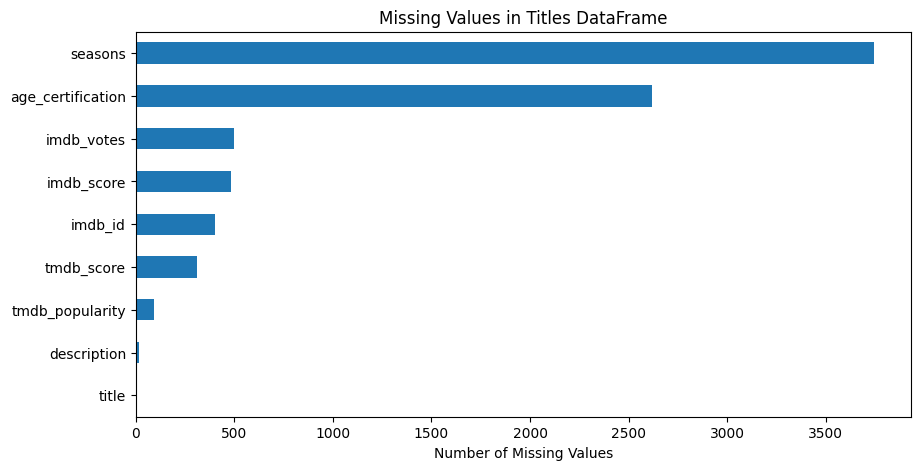

In [ ]:
plt.figure(figsize=(10, 5))
missing_titles[missing_titles > 0].sort_values().plot(kind='barh')
plt.title('Missing Values in Titles DataFrame')
plt.xlabel('Number of Missing Values')
plt.show()

In [ ]:
# seasons: For 'MOVIE' type, NaNs are expected. For 'SHOW', NaNs might mean 1 season or missing data.
# Fill NaN seasons with 0 for movies and 1 for shows if NaN (assuming a show has at least 1 season if listed)
titles_df.loc[titles_df['type'] == 'MOVIE', 'seasons'] = titles_df.loc[titles_df['type'] == 'MOVIE', 'seasons'].fillna(0)
titles_df.loc[titles_df['type'] == 'SHOW', 'seasons'] = titles_df.loc[titles_df['type'] == 'SHOW', 'seasons'].fillna(1)

In [ ]:
# title, age_certification, imdb_id: Impute with 'Unknown'
for col in ['title', 'age_certification', 'imdb_id']:
    titles_df[col] = titles_df[col].fillna('Unknown')

In [ ]:
# imdb_score, imdb_votes, tmdb_popularity, tmdb_score: Impute with median (robust to outliers)
for col in ['imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']:
    titles_df[col] = titles_df[col].fillna(titles_df[col].median())

In [ ]:
# description: Impute with an empty string
titles_df['description'] = titles_df['description'].fillna('')

In [ ]:
# genres, production_countries: These are string representations of lists.
# If NaN, it means no genres/countries were listed. Fill with string representation of empty list '[]'
for col in ['genres', 'production_countries']:
    titles_df[col] = titles_df[col].fillna('[]')

In [ ]:
print("\n--- Missing Values After Handling (Titles) ---")
print(titles_df.isna().sum())


--- Missing Values After Handling (Titles) ---
id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
dtype: int64


#### Credits DataFrame

In [ ]:
print("--- Missing Values Before Handling (Credits) ---")
missing_credits = credits_df.isna().sum()
print(missing_credits)

--- Missing Values Before Handling (Credits) ---
person_id       0
id              0
name            0
character    9772
role            0
dtype: int64


In [ ]:
credits_df[credits_df['character'].isna() & (credits_df['role'] != 'DIRECTOR')].head()

,person_id,id,name,character,role
182,548006,tm70993,Peter Brett,NaN,ACTOR
364,557168,tm135083,Loutfi El Hakim,NaN,ACTOR
366,557170,tm135083,F. El Demerdache,NaN,ACTOR
367,557171,tm135083,Said El Araby,NaN,ACTOR
369,557172,tm135083,Hana Abdel Fattah,NaN,ACTOR


In [ ]:
# character: Impute with "N/A"
credits_df['character'] = credits_df['character'].fillna('N/A')

In [ ]:
print("--- Missing Values After Handling (Credits) ---")
print(credits_df.isna().sum())

--- Missing Values After Handling (Credits) ---
person_id    0
id           0
name         0
character    0
role         0
dtype: int64


### 1.4 Data Type Conversion

In [ ]:
print("--- Data Types After Imputation (Titles) ---")
print(titles_df.dtypes)

--- Data Types After Imputation (Titles) ---
id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                 float64
imdb_id                  object
imdb_score              float64
imdb_votes              float64
tmdb_popularity         float64
tmdb_score              float64
dtype: object


In [ ]:
# seasons, imdb_votes should be 'int'
# imdb_score, tmdb_popularity, tmdb_score can remain 'float'
for col in ['seasons', 'imdb_votes']:
    titles_df[col] = titles_df[col].astype(int)

In [ ]:
print("--- Data Types After Conversion (Titles) ---")
print(titles_df.dtypes)

--- Data Types After Conversion (Titles) ---
id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                   int64
imdb_id                  object
imdb_score              float64
imdb_votes                int64
tmdb_popularity         float64
tmdb_score              float64
dtype: object


### 1.5 Parse List-like Columns in Titles DataFrame

In [ ]:
# The 'genres' and 'production_countries' columns are strings that look like lists. We need to convert them into actual lists.
import ast
def convert_to_list(string_list):
    try:
        evaluated_list = ast.literal_eval(string_list)
        if isinstance(evaluated_list, list):
            # Ensure all items in the list are strings and clean them
            return [str(item).strip() for item in evaluated_list if str(item).strip()]
        else:
            print(f"Warning: ast.literal_eval did not return a list.")
            return [string_list] if string_list else []

    except (SyntaxError, ValueError):
        return []

titles_df['genres_list'] = titles_df['genres'].apply(convert_to_list)
titles_df['countries_list'] = titles_df['production_countries'].apply(convert_to_list)

titles_df[['genres', 'genres_list', 'production_countries', 'countries_list']].head()

,genres,genres_list,production_countries,countries_list
0,['documentation'],[documentation],['US'],[US]
1,"['drama', 'crime']","[drama, crime]",['US'],[US]
2,"['drama', 'action', 'thriller', 'european']","[drama, action, thriller, european]",['US'],[US]
3,"['fantasy', 'action', 'comedy']","[fantasy, action, comedy]",['GB'],[GB]
4,"['war', 'action']","[war, action]","['GB', 'US']","[GB, US]"


### 1.6 Merge Datasets

In [ ]:
# Merge credits_df into titles_df based on the common 'id' column.
merged_df = pd.merge(titles_df, credits_df, on='id', how='left')

print("--- Merged DataFrame ---")
print("Shape:", merged_df.shape)
print("\nInfo:")
merged_df.info()

--- Merged DataFrame ---
Shape: (78162, 21)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78162 entries, 0 to 78161
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    78162 non-null  object 
 1   title                 78162 non-null  object 
 2   type                  78162 non-null  object 
 3   description           78162 non-null  object 
 4   release_year          78162 non-null  int64  
 5   age_certification     78162 non-null  object 
 6   runtime               78162 non-null  int64  
 7   genres                78162 non-null  object 
 8   production_countries  78162 non-null  object 
 9   seasons               78162 non-null  int64  
 10  imdb_id               78162 non-null  object 
 11  imdb_score            78162 non-null  float64
 12  imdb_votes            78162 non-null  int64  
 13  tmdb_popularity       78162 non-null  float64
 14  tmdb_score         

In [ ]:
print("\nFirst 5 rows:")
merged_df.head()


First 5 rows:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,genres_list,countries_list,person_id,name,character,role
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1,Unknown,6.6,2233,0.600,6.900,[documentation],[US],NaN,NaN,NaN,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],0,tt0075314,8.2,808582,40.965,8.179,"[drama, crime]",[US],3748.0,Robert De Niro,Travis Bickle,ACTOR
2,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],0,tt0075314,8.2,808582,40.965,8.179,"[drama, crime]",[US],14658.0,Jodie Foster,Iris Steensma,ACTOR
3,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],0,tt0075314,8.2,808582,40.965,8.179,"[drama, crime]",[US],7064.0,Albert Brooks,Tom,ACTOR
4,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],0,tt0075314,8.2,808582,40.965,8.179,"[drama, crime]",[US],3739.0,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR


**Observation:**
- `person_id`, `name`, `character`, `role` columns might have NaNs if an id in `titles_df` had no corresponding entry in `credits_df`.

### 1.7 Aggregate Credit Information

In [ ]:
# We want one row per title, with lists of actors and directors.
# Check 'role' column
merged_df['role'].unique()

array([nan, 'ACTOR', 'DIRECTOR'], dtype=object)

In [ ]:
merged_df['role'] = merged_df['role'].fillna('Unknown')

In [ ]:
# Aggregate actors list
actors = merged_df[merged_df['role'] == 'ACTOR'].groupby('id')['name'].apply(list).reset_index()
actors.rename(columns={'name': 'actors_list'}, inplace=True)

In [ ]:
# Aggregate directors list
directors = merged_df[merged_df['role'] == 'DIRECTOR'].groupby('id')['name'].apply(list).reset_index()
directors.rename(columns={'name': 'directors_list'}, inplace=True)

In [ ]:
# Merge aggregated lists back to titles_df
df_actors = pd.merge(titles_df, actors, on='id', how='left')
df_final = pd.merge(df_actors, directors, on='id', how='left')

In [ ]:
# Fill NaN for actors_list/directors_list with empty lists if a title had no actors/directors
for col in ['actors_list', 'directors_list']:
    df_final[col] = df_final[col].apply(lambda x: x if isinstance(x, list) else [])

In [ ]:
print("--- Final DataFrame with Aggregated Credits ---")
print("Shape:", df_final.shape)
print("\nInfo:")
df_final.info()

--- Final DataFrame with Aggregated Credits ---
Shape: (5850, 19)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5850 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5850 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     5850 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               5850 non-null   int64  
 10  imdb_id               5850 non-null   object 
 11  imdb_score            5850 non-null   float64
 12  imdb_votes            5850 non-null   int64  
 13  tmdb_popularity       5850 non-null   float64
 14 

In [ ]:
df_final[['title', 'actors_list', 'directors_list']].sample(5)

,title,actors_list,directors_list
5364,The Phantom,[],[Patrick Forbes]
249,Blade Runner: The Final Cut,[],[]
1568,Umrika,"[Suraj Sharma, Tony Revolori, Prateik Babbar, ...",[Prashant Nair]
338,"10,000 BC","[Steven Strait, Camilla Belle, Cliff Curtis, N...",[Roland Emmerich]
216,Breaking Bad,"[Bryan Cranston, Aaron Paul, Anna Gunn, Dean N...",[]


In [ ]:
# Drop the original 'genres' and 'production_countries'
df_final = df_final.drop(columns=['genres', 'production_countries'])

# Rename for consistency
df_final = df_final.rename(columns={'genres_list': 'genres', 'countries_list': 'production_countries'})

In [ ]:
df_final.sample(2)

,id,title,type,description,release_year,age_certification,runtime,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,genres,production_countries,actors_list,directors_list
283,tm46436,Thir13en Ghosts,MOVIE,"Arthur and his two children, Kathy and Bobby, ...",2001,R,91,0,tt0245674,5.6,87083,50.592,6.2,"[horror, thriller, fantasy]","[CA, US]","[Tony Shalhoub, Embeth Davidtz, Matthew Lillar...",[Steve Beck]
2118,ts80959,Sacred Games,SHOW,A link in their pasts leads an honest cop to a...,2018,TV-MA,50,2,tt6077448,8.5,86279,14.613,8.1,"[action, drama, crime, thriller]",[IN],"[Pankaj Tripathi, Nawazuddin Siddiqui, Chittar...","[Neeraj Ghaywan, Vikramaditya Motwane, Anurag ..."


### 1.8 Text Cleaning (`description`)

In [ ]:
df_final['description'].to_list()[100:105]

['Years ago, the fearsome Pirate King, Gol D. Roger was executed leaving a huge pile of treasure and the famous "One Piece" behind. Whoever claims the "One Piece" will be named the new King of the Pirates. Monkey D. Luffy, a boy who consumed a "Devil Fruit," decides to follow in the footsteps of his idol, the pirate Shanks, and find the One Piece. It helps, of course, that his body has the properties of rubber and that he\'s surrounded by a bevy of skilled fighters and thieves to help him along the way. Luffy will do anything to get the One Piece and become King of the Pirates!',
 "Each Challenge pits numerous cast members from past seasons of reality shows against each other, dividing them into two separate teams according to different criteria, such as gender, which show they first appeared on, whether or not they're veterans or rookies on the show, etc. The two teams compete in numerous missions in order to win prizes and advance in the overall game.",
 "101-year-old Rose DeWitt Buk

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and numbers, keep letters, space
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    words = text.split()
    # Lemmatize and remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 1]
    # Join the words back into a single string
    cleaned_text = ' '.join(words)
    return cleaned_text

df_final['description_cleaned'] = df_final['description'].apply(clean_text)

In [ ]:
print("Original Description:\n", df_final['description'].iloc[100])
print("\nCleaned Description:\n", df_final['description_cleaned'].iloc[100])

Original Description:
 Years ago, the fearsome Pirate King, Gol D. Roger was executed leaving a huge pile of treasure and the famous "One Piece" behind. Whoever claims the "One Piece" will be named the new King of the Pirates. Monkey D. Luffy, a boy who consumed a "Devil Fruit," decides to follow in the footsteps of his idol, the pirate Shanks, and find the One Piece. It helps, of course, that his body has the properties of rubber and that he's surrounded by a bevy of skilled fighters and thieves to help him along the way. Luffy will do anything to get the One Piece and become King of the Pirates!

Cleaned Description:
 year ago fearsome pirate king gol roger executed leaving huge pile treasure famous one piece behind whoever claim one piece named new king pirate monkey luffy boy consumed devil fruit decides follow footstep idol pirate shank find one piece help course body property rubber he surrounded bevy skilled fighter thief help along way luffy anything get one piece become king p

### 1.9 Final check of the processed DataFrame

In [ ]:
print("--- Final DataFrame ---")
print("Shape:", df_final.shape)
print("\nInfo:")
df_final.info()
print("\nMissing Values:")
print(df_final.isna().sum())

--- Final DataFrame ---
Shape: (5850, 18)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5850 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5850 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     5850 non-null   object 
 6   runtime               5850 non-null   int64  
 7   seasons               5850 non-null   int64  
 8   imdb_id               5850 non-null   object 
 9   imdb_score            5850 non-null   float64
 10  imdb_votes            5850 non-null   int64  
 11  tmdb_popularity       5850 non-null   float64
 12  tmdb_score            5850 non-null   float64
 13  genres                5850 non-null   object 
 14  production_countries  5

In [ ]:
df_final.to_parquet('netflix_processed_data.parquet', engine='pyarrow')

## 2. Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_parquet('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/netflix/data/netflix_processed_data.parquet', engine='pyarrow')

In [ ]:
sns.set_style('whitegrid')

In [ ]:
df.sample(5)

,id,title,type,description,release_year,age_certification,runtime,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,genres,production_countries,actors_list,directors_list,description_cleaned
750,tm177958,Pyaar Ka Punchnama,MOVIE,Nishant starts dating Charu while his roommate...,2011,PG-13,149,0,tt1926313,7.6,21521,4.851,7.0,"[romance, drama, comedy, european]",[IN],[],[Esen Işık],nishant start dating charu roommate rajat vikr...
3782,ts255809,Carmel: Who Killed Maria Marta?,SHOW,Documentary series on the circumstances surrou...,2020,TV-14,58,1,tt13244092,7.0,2463,33.319,7.5,"[documentation, crime]",[AR],"[María Marta García Belsunce, Carlos Carrascos...",[Alejandro Hartmann],documentary series circumstance surrounding de...
5587,tm1119455,Camp Confidential: America's Secret Nazis,MOVIE,"Camp Confidential: America's Secret Nazis, is ...",2021,PG-13,34,0,tt15470770,6.3,2233,14.501,7.1,"[documentation, animation, history]",[US],"[Arno Mayer, Peter Wiess, Dwight D. Eisenhower...","[Daniel Sivan, Mor Loushy]",camp confidential america secret nazi document...
2349,ts84346,Falsa identidad,SHOW,"Isabel and Diego, two complete strangers, must...",2018,TV-14,43,2,tt8598690,7.0,358,206.288,7.5,"[crime, action, drama, thriller]","[US, MX]","[Luis Ernesto Franco, Camila Sodi, Dulce María...",[],isabel diego two complete stranger must assume...
4845,tm851128,Bigbug,MOVIE,"Set in the world of 2045, where communities ha...",2022,R,111,0,tt11541872,5.4,7483,26.497,5.3,"[comedy, scifi, fantasy]",[FR],"[Isabelle Nanty, Elsa Zylberstein, Claude Perr...",[Jean-Pierre Jeunet],set world community robotic helper group subur...


### 2.1 Univariate Analysis

#### Note: Kernel Density Estimate (`kde=True` in `sns.histplot`):
- A smooth curve that represents the probability density function (PDF) of the underlying data.
- It's useful for visualizing the overall shape, identifying peaks (modes), and understanding the general form of the data distribution without being tied to specific bin widths of a histogram.

#### Distribution of 'type' (Movie vs. Show)

type
MOVIE    3744
SHOW     2106
Name: count, dtype: int64


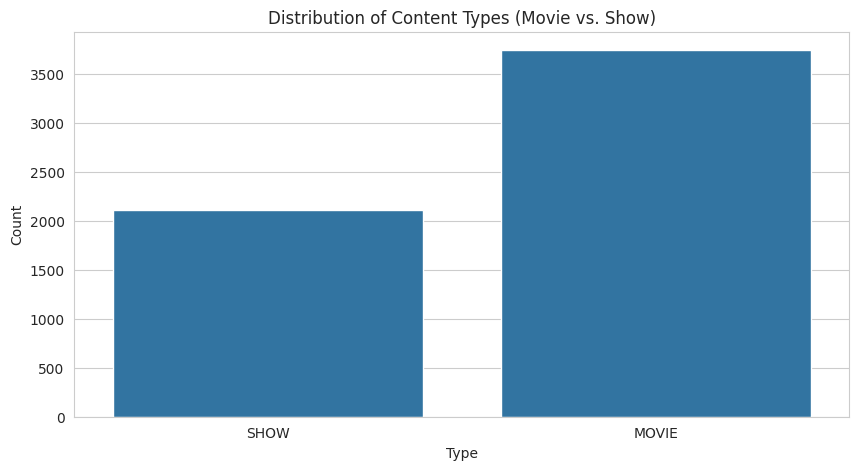

In [ ]:
type_counts = df['type'].value_counts()
print(type_counts)

plt.figure(figsize=(10, 5))
sns.countplot(x='type', data=df)
plt.title('Distribution of Content Types (Movie vs. Show)')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

#### Distribution of 'release_year'

Earliest Release Year: 1945
Latest Release Year: 2022


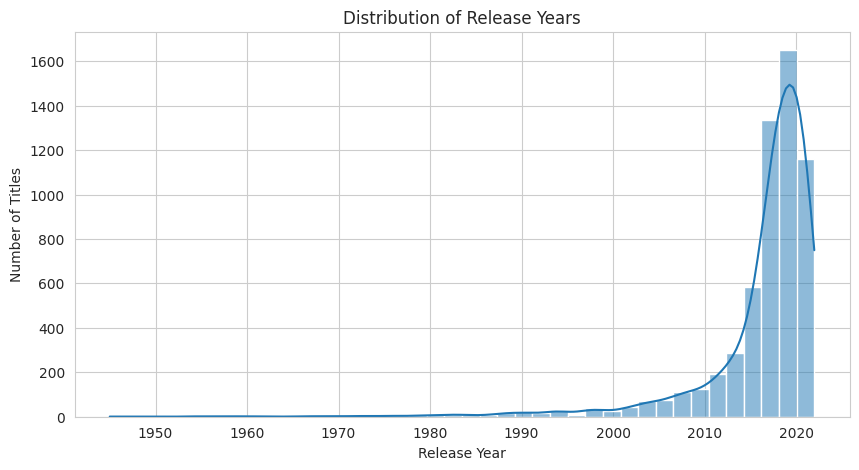

In [ ]:
print(f"Earliest Release Year: {df['release_year'].min()}")
print(f"Latest Release Year: {df['release_year'].max()}")

plt.figure(figsize=(10, 5))
sns.histplot(df['release_year'], bins=40, kde=True)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

#### Frequency of 'age_certification'

age_certification
Unknown    2619
TV-MA       883
R           556
TV-14       474
PG-13       451
PG          233
TV-PG       188
G           124
TV-Y7       120
TV-Y        107
TV-G         79
NC-17        16
Name: count, dtype: int64


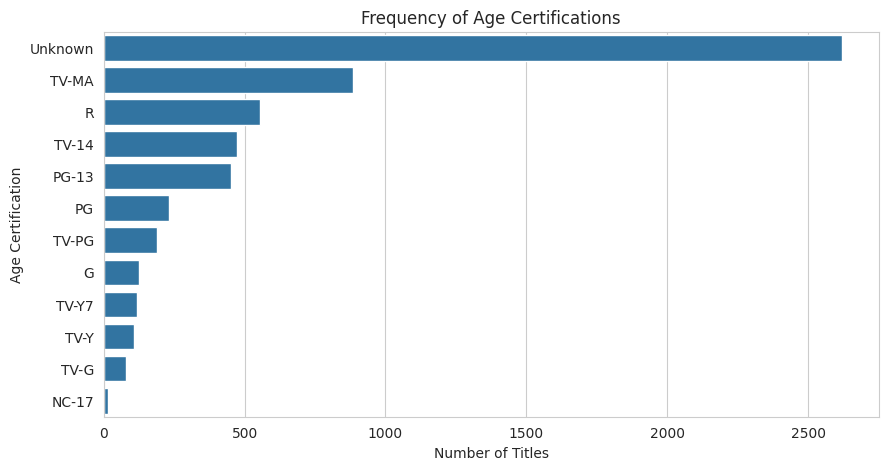

In [ ]:
age_count = df['age_certification'].value_counts()
print(age_count)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='age_certification', order=age_count.index)
plt.title('Frequency of Age Certifications')
plt.xlabel('Number of Titles')
plt.ylabel('Age Certification')
plt.show()

#### Distribution of 'runtime' for movies

count    3744.000000
mean       98.213675
std        30.640640
min         2.000000
25%        85.000000
50%        98.000000
75%       115.000000
max       240.000000
Name: runtime, dtype: float64


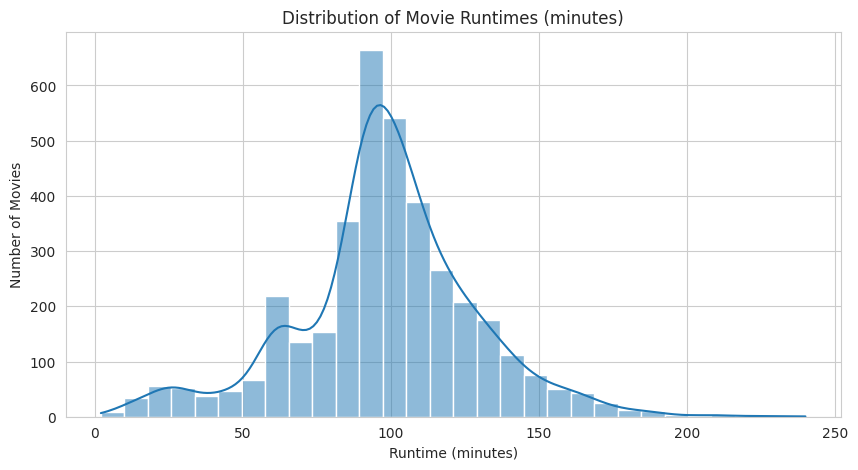

In [ ]:
movie_runtime = df[df['type'] == 'MOVIE']['runtime']
print(movie_runtime.describe())

plt.figure(figsize=(10, 5))
sns.histplot(movie_runtime, bins=30, kde=True)
plt.title('Distribution of Movie Runtimes (minutes)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.show()

#### Distribution of 'seasons' for shows

count    2106.000000
mean        2.162868
std         2.689041
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        42.000000
Name: seasons, dtype: float64


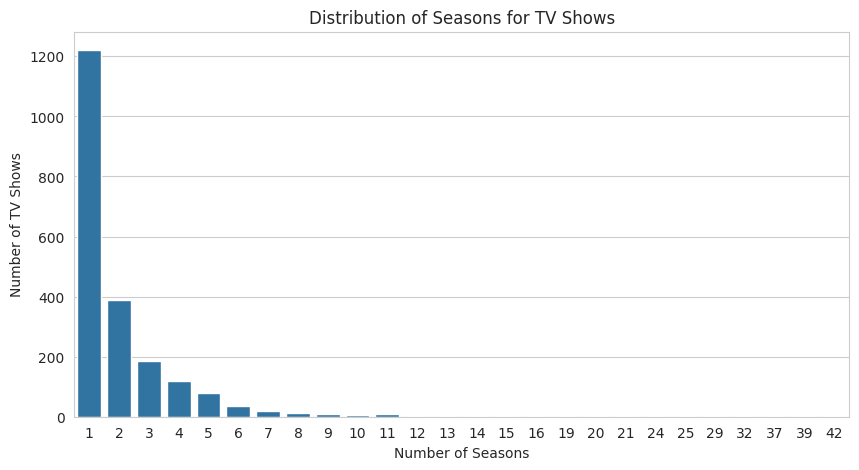

In [ ]:
show_seasons = df[df['type'] == 'SHOW']['seasons']
show_seasons_filtered = show_seasons[show_seasons > 0]
print(show_seasons_filtered.describe())

plt.figure(figsize=(10, 5))
sns.countplot(x=show_seasons_filtered, data=df)
plt.title('Distribution of Seasons for TV Shows')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.show()

#### Distribution of 'imdb_score'

count    5850.000000
mean        6.518205
std         1.115111
min         1.500000
25%         5.900000
50%         6.600000
75%         7.300000
max         9.600000
Name: imdb_score, dtype: float64


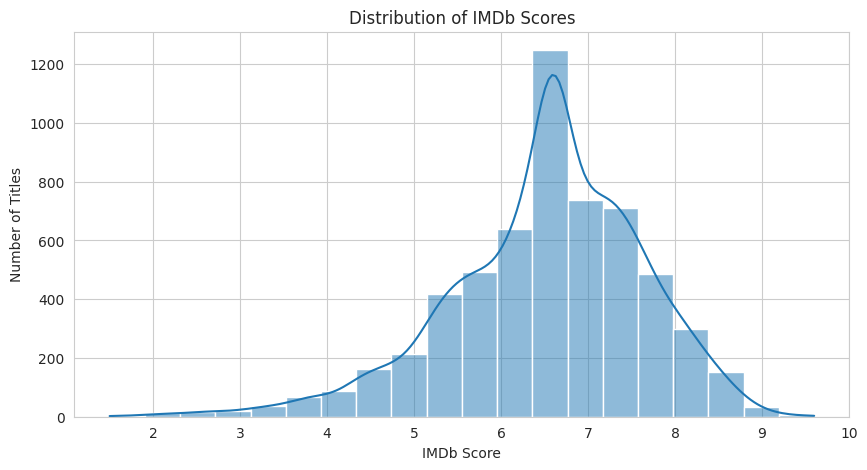

In [ ]:
print(df['imdb_score'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['imdb_score'], bins=20, kde=True)
plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Number of Titles')
plt.show()

#### Distribution of 'imdb_votes'

count    5.850000e+03
mean     2.163412e+04
std      9.184143e+04
min      5.000000e+00
25%      6.042500e+02
50%      2.233000e+03
75%      7.976000e+03
max      2.294231e+06
Name: imdb_votes, dtype: float64


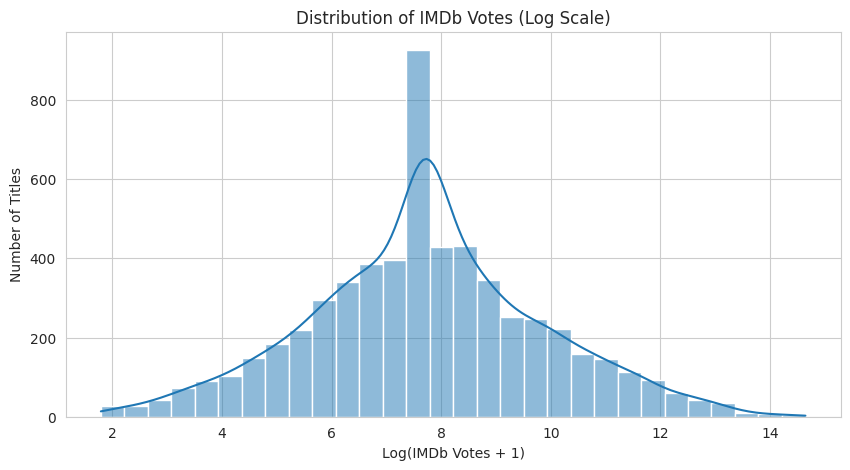

In [ ]:
print(df['imdb_votes'].describe())

# use log scale for better visualization
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['imdb_votes']), bins=30, kde=True)
plt.title('Distribution of IMDb Votes (Log Scale)')
plt.xlabel('Log(IMDb Votes + 1)')
plt.ylabel('Number of Titles')
plt.show()

#### Most common 'genres'

In [ ]:
# The 'genres' column contains lists of genres. We need to flatten it first.
from collections import Counter

# Check genre is not empty
all_genres = [genre for sublist in df['genres'] for genre in sublist if genre]
genre_counts = Counter(all_genres)
top_15_genres = genre_counts.most_common(15)
print(top_15_genres)

[('drama', 2968), ('comedy', 2325), ('thriller', 1228), ('action', 1157), ('romance', 971), ('documentation', 952), ('crime', 936), ('animation', 705), ('family', 682), ('fantasy', 630), ('scifi', 589), ('european', 443), ('horror', 378), ('music', 262), ('history', 254)]


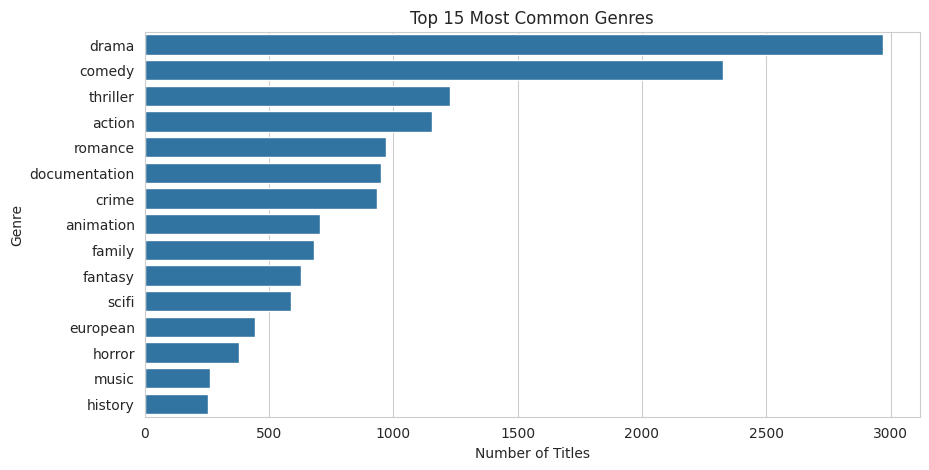

In [ ]:
genre_df = pd.DataFrame(top_15_genres, columns=['genre', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_df, x='count', y='genre')
plt.title('Top 15 Most Common Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

#### Most common 'production_countries'

In [ ]:
!pip install pycountry
import pycountry

In [ ]:
def get_country(code):
    try:
        country = pycountry.countries.get(alpha_2=code.upper())
        return country.name if country else code
    except (LookupError, AttributeError):
        return code

In [ ]:
all_countries = [country for sublist in df['production_countries'] for country in sublist if country]
country_counts = Counter(all_countries)
top_15_countries = country_counts.most_common(15)
print(top_15_countries)

[('US', 2323), ('IN', 622), ('GB', 404), ('JP', 287), ('FR', 248), ('KR', 228), ('CA', 219), ('ES', 211), ('DE', 139), ('MX', 126), ('BR', 102), ('CN', 102), ('PH', 86), ('AU', 84), ('TR', 84)]


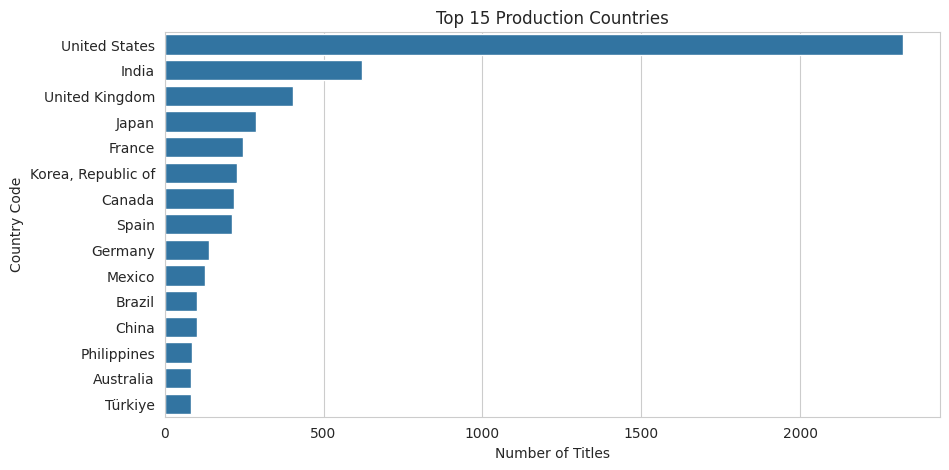

In [ ]:
country_data = []
for code, count in top_15_countries:
    country_name = get_country(code)
    country_data.append({'country_code': code, 'country_name': country_name, 'count': count})

countries_df = pd.DataFrame(country_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=countries_df, x='count', y='country_name')
plt.title('Top 15 Production Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country Code')
plt.show()

### 2.2 Bivariate & Multivariate Analysis

#### IMDb Score vs. Type (Movie/Show)

        count      mean       std  min  25%  50%  75%  max
type                                                      
MOVIE  3744.0  6.276469  1.083448  1.5  5.6  6.5  7.0  9.1
SHOW   2106.0  6.947958  1.038814  2.0  6.5  7.0  7.7  9.6


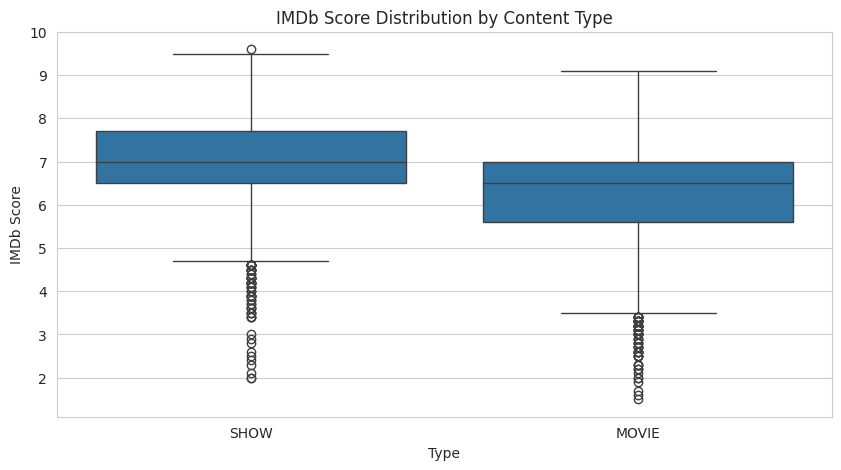

In [ ]:
print(df.groupby('type')['imdb_score'].describe())
plt.figure(figsize=(10, 5))
sns.boxplot(x='type', y='imdb_score', data=df)
plt.title('IMDb Score Distribution by Content Type')
plt.xlabel('Type')
plt.ylabel('IMDb Score')
plt.show()

##### IMDb Score vs. Runtime (for Movies)

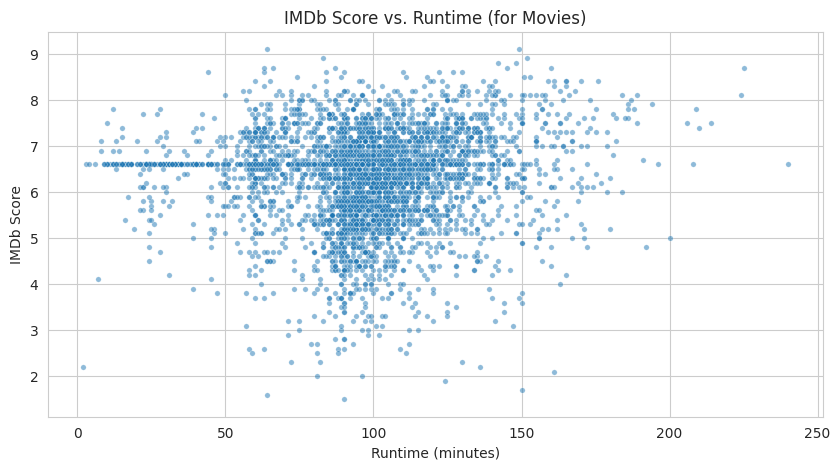

In [ ]:
plt.figure(figsize=(10, 5))
movie_df = df[df['type'] == 'MOVIE']
sns.scatterplot(data=movie_df, x='runtime', y='imdb_score', s=15, alpha=0.5)
plt.title('IMDb Score vs. Runtime (for Movies)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('IMDb Score')
plt.show()

##### IMDb Score vs. Number of Seasons (for Shows)

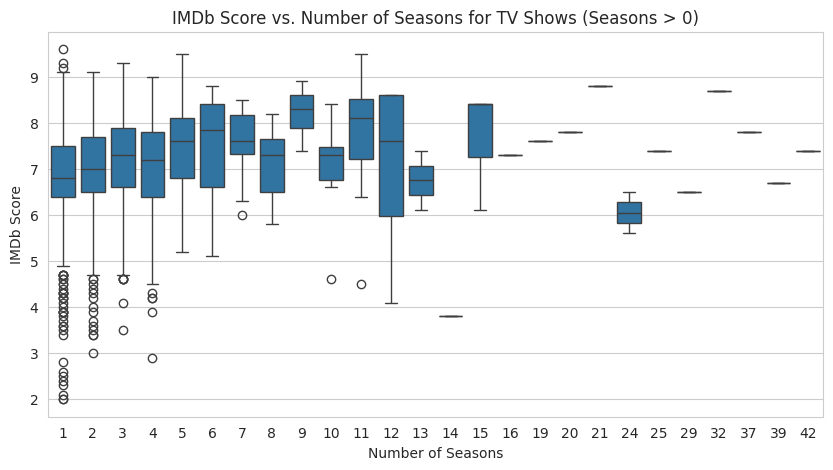

In [ ]:
plt.figure(figsize=(10, 5))
show_df = df[df['type'] == 'SHOW']
# Use boxplot for categorical season counts
sns.boxplot(data=show_df[show_df['seasons'] > 0], x='seasons', y='imdb_score')
plt.title('IMDb Score vs. Number of Seasons for TV Shows (Seasons > 0)')
plt.xlabel('Number of Seasons')
plt.ylabel('IMDb Score')
plt.xticks(rotation='horizontal')
plt.show()

#### IMDb Score vs. Release Year

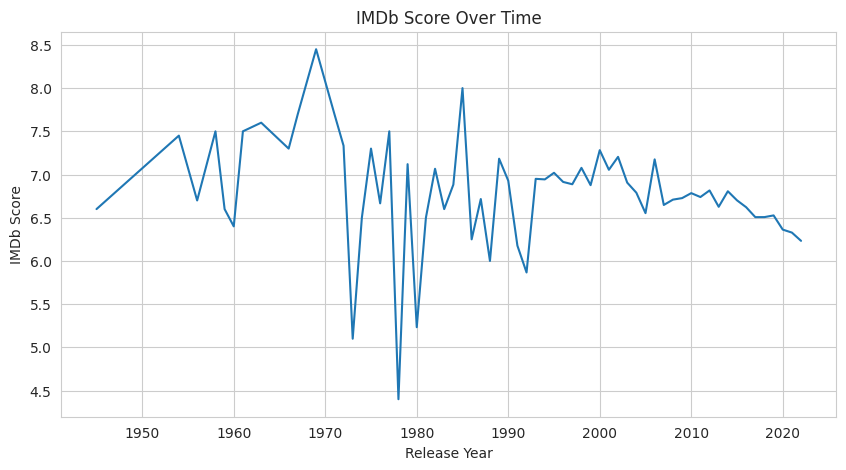

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='release_year', y='imdb_score', errorbar=None)
plt.title('IMDb Score Over Time')
plt.xlabel('Release Year')
plt.ylabel('IMDb Score')
plt.show()

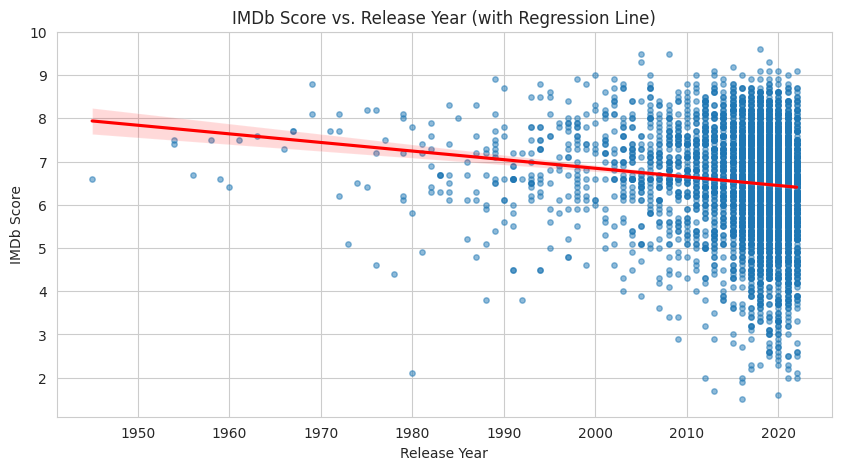

In [ ]:
# scatterplot with regression
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='release_year', y='imdb_score',
            scatter_kws={'alpha':0.5, 's':15},
            line_kws={'color':'red'},)
plt.title('IMDb Score vs. Release Year (with Regression Line)')
plt.xlabel('Release Year')
plt.ylabel('IMDb Score')
plt.show()

#### Content Trends Over Time

##### Titles by release year

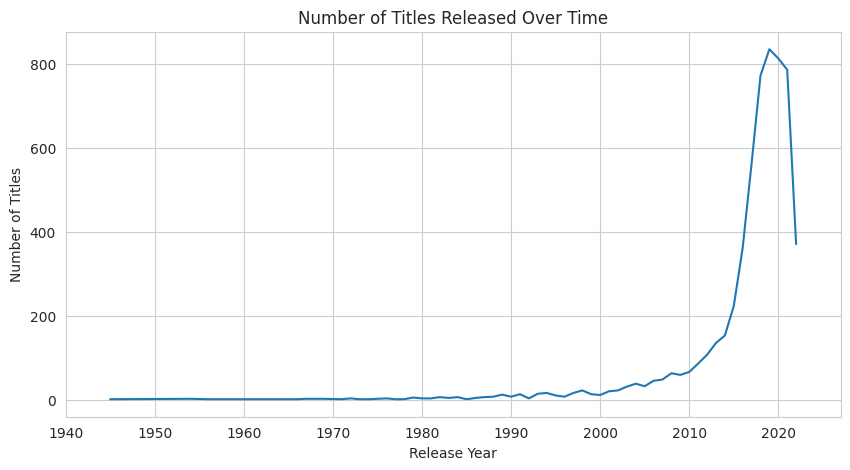

In [ ]:
titles_by_year = df.groupby('release_year')['id'].count().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=titles_by_year, x='release_year', y='id')
plt.title('Number of Titles Released Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xlim(df['release_year'].min() - 5, df['release_year'].max() + 5)
plt.show()

##### Titles by type, release year

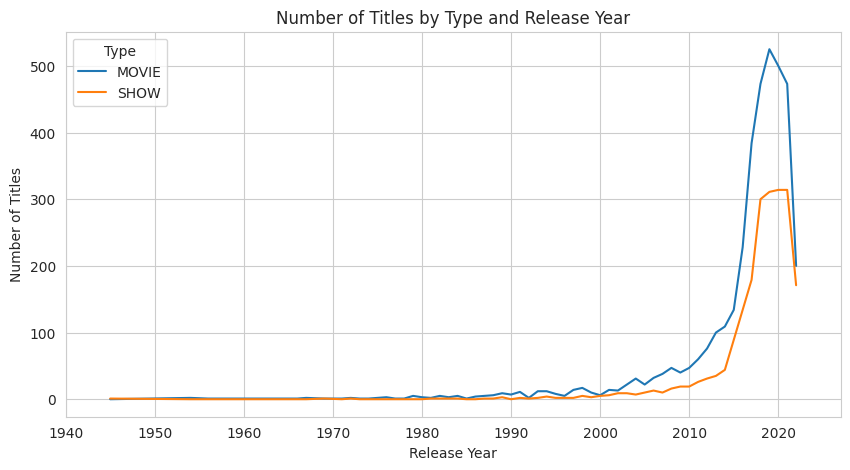

In [ ]:
titles_by_type_year = df.groupby(['release_year', 'type'])['id'].count().unstack().fillna(0)

titles_by_type_year.plot(kind='line', figsize=(10, 5))
plt.title('Number of Titles by Type and Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xlim(df['release_year'].min() - 5, df['release_year'].max() + 5)
plt.legend(title='Type')
plt.show()

#### Top Directors/Actors by Number of Titles and by Average IMDb Score

##### Top 10 Directors by number of titles

In [ ]:
directors = [d for sublist in df['directors_list'] for d in sublist if d]
director_counts = Counter(directors)
top_10_directors = director_counts.most_common(10)
directors_df = pd.DataFrame(top_10_directors, columns=['director', 'title_count'])
directors_df

,director,title_count
0,Raúl Campos,20
1,Jan Suter,19
2,Ryan Polito,17
3,Jay Karas,15
4,Marcus Raboy,14
5,Cathy Garcia-Molina,12
6,Jay Chapman,12
7,Youssef Chahine,11
8,Anurag Kashyap,8
9,Troy Miller,8


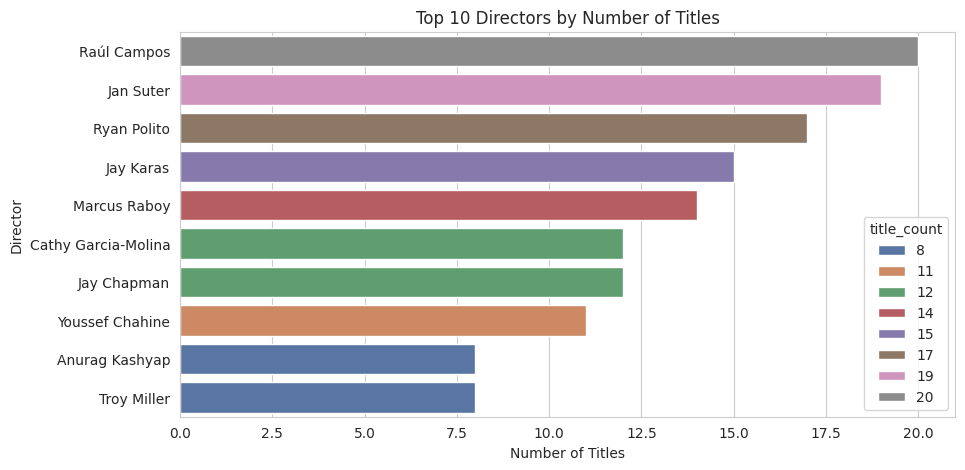

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=directors_df, x='title_count', y='director', hue='title_count', palette='deep')
plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

##### Top 10 Actors by number of titles

In [ ]:
actors = [a for sublist in df['actors_list'] for a in sublist if a]
actor_counts = Counter(actors)
top_10_actors = actor_counts.most_common(10)
actors_df = pd.DataFrame(top_10_actors, columns=['actor', 'title_count'])
actors_df

,actor,title_count
0,Kareena Kapoor Khan,25
1,Boman Irani,25
2,Shah Rukh Khan,23
3,Takahiro Sakurai,21
4,Amitabh Bachchan,20
5,Paresh Rawal,20
6,Priyanka Chopra Jonas,20
7,Anupam Kher,19
8,Junichi Suwabe,19
9,Yuki Kaji,19


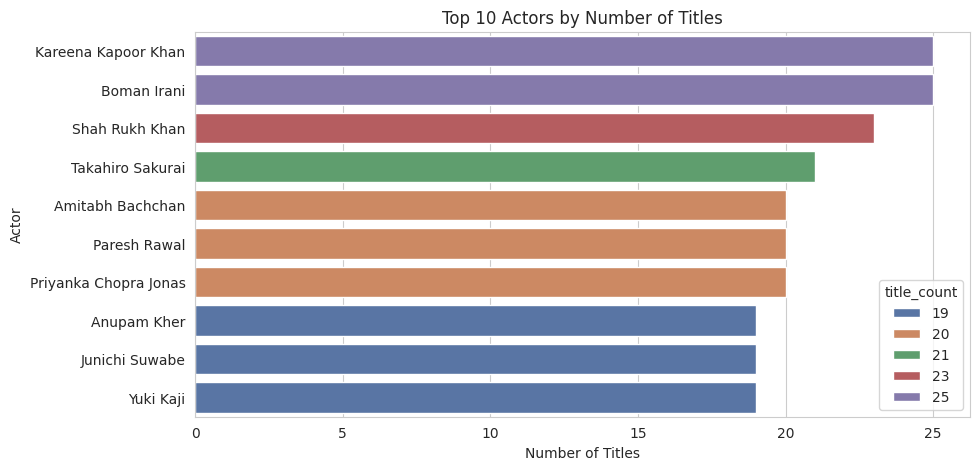

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=actors_df, x='title_count', y='actor', hue='title_count', palette='deep')
plt.title('Top 10 Actors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')
plt.show()

#### Average IMDb score by Top Genres

In [ ]:
# --- Conversion Step: Ensure df['genres'] contains Python lists ---
print("--- Converting df['genres'] cells to Python lists (if they are numpy.ndarray) ---")

def convert_to_list_if_ndarray(cell_value):
    if isinstance(cell_value, np.ndarray):
        return cell_value.tolist() # Convert ndarray to Python list
    elif isinstance(cell_value, list):
        return cell_value # Already a list, no change needed
    elif pd.isna(cell_value): # Handle potential NaNs that might not be ndarray or list
        return []
    else:
        # If it's something else (e.g. a string that wasn't caught by ast.literal_eval earlier)
        print(f"Warning: Cell in 'genres' is neither ndarray nor list: {cell_value} (type: {type(cell_value)}). Returning as empty list.")
        return []

if 'genres' in df.columns:
    # Apply the conversion
    df['genres'] = df['genres'].apply(convert_to_list_if_ndarray)

    # Verification after conversion
    print("\nVerification after attempting ndarray to list conversion:")
    if not df.empty and 'genres' in df.columns and not df['genres'].empty:
        sample_cell_after_conversion = df['genres'].iloc[0]
        print(f"Type of first cell in df['genres'] AFTER conversion: {type(sample_cell_after_conversion)}")
        if isinstance(sample_cell_after_conversion, list):
            print("Conversion successful: Cells are now Python lists.")
            if sample_cell_after_conversion:
                print(f"First item in the first list: '{sample_cell_after_conversion[0]}' (type: {type(sample_cell_after_conversion[0])})")
        else:
            print("Conversion might not have worked as expected. First cell is still not a Python list.")
    else:
        print("DataFrame or 'genres' column is empty after conversion attempt.")
else:
    print("'genres' column not found in df.")

--- Converting df['genres'] cells to Python lists (if they are numpy.ndarray) ---

Verification after attempting ndarray to list conversion:
Type of first cell in df['genres'] AFTER conversion: <class 'list'>
Conversion successful: Cells are now Python lists.
First item in the first list: 'documentation' (type: <class 'str'>)


In [ ]:
genre_avg_scores_list = []
for genre_tuple in top_15_genres:
    genre_name = genre_tuple[0]
    title_count = genre_tuple[1]

    try:
        genre_titles = df[df['genres'].apply(lambda x: genre_name in x if isinstance(x, list) else False)]
    except Exception as e:
        print(f"An error occurred during filtering for genre '{genre_name}': {e}")
        genre_titles = pd.DataFrame() # Create an empty DataFrame on error to proceed

    if not genre_titles.empty:
        avg_score = genre_titles['imdb_score'].mean()
        titles_found_count = len(genre_titles)

        genre_avg_scores_list.append({
            'genre': genre_name,
            'avg_imdb_score': avg_score, # Key used for the column
            'title_count': titles_found_count
        })
    else:
        # Filtering resulted in an empty DataFrame for this genre
        print(f"Warning: No titles found when filtering for genre '{genre_name}'.")

if genre_avg_scores_list: # Check if the list is not empty
    genre_scores_df = pd.DataFrame(genre_avg_scores_list)
    genre_avg_scores_df = genre_scores_df.sort_values(by='avg_imdb_score', ascending=False)
    print(genre_avg_scores_df)

            genre  avg_imdb_score  title_count
14        history        7.128740          254
5   documentation        6.969223          952
7       animation        6.691206          705
6           crime        6.648932          936
0           drama        6.623450         2968
9         fantasy        6.558889          630
10          scifi        6.547878          589
11       european        6.532054          443
13          music        6.518321          262
3          action        6.428349         1157
1          comedy        6.403785         2325
4         romance        6.382492          971
2        thriller        6.377606         1228
8          family        6.344135          682
12         horror        6.025132          378


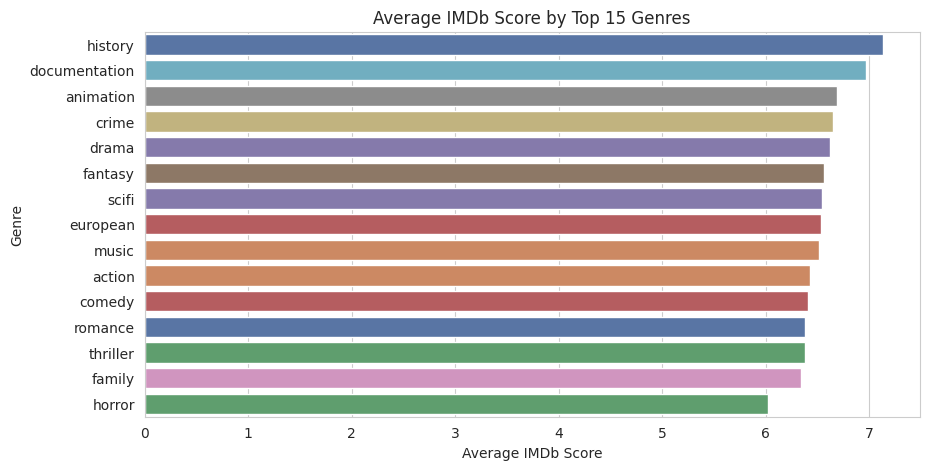

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=genre_avg_scores_df, x='avg_imdb_score', y='genre', palette='deep', hue='title_count', legend=False)
plt.title('Average IMDb Score by Top 15 Genres')
plt.xlabel('Average IMDb Score')
plt.ylabel('Genre')
plt.show()

#### Correlation Heatmap for numerical features

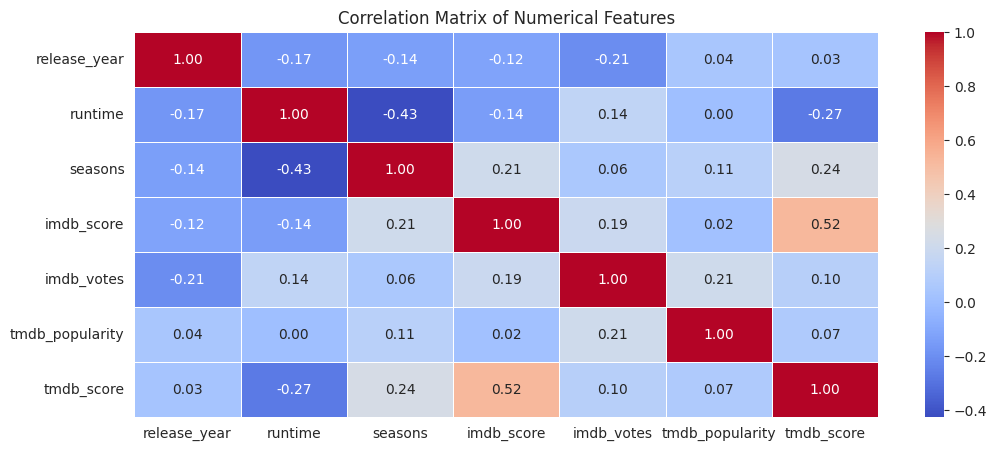

In [ ]:
numerical_cols = ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=0)
plt.show()

### 2.3 Text Analysis on Descriptions

#### Word Cloud for all cleaned descriptions

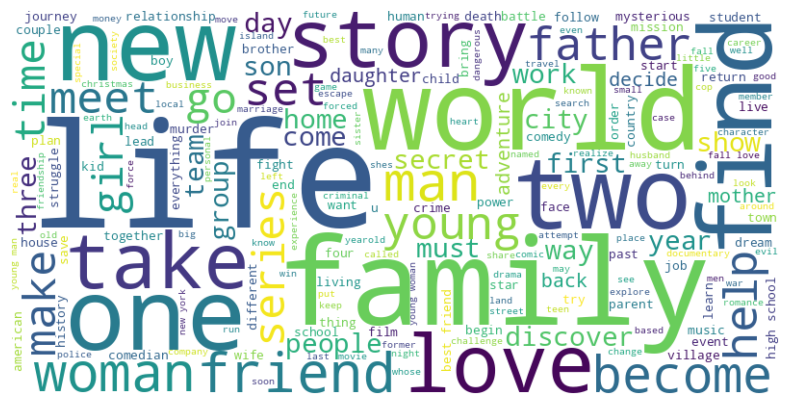

In [ ]:
from wordcloud import WordCloud
all_cleaned_descriptions = " ".join(df['description_cleaned'].dropna())

if all_cleaned_descriptions.strip(): # Check if there's any text to plot
    wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(all_cleaned_descriptions)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_all, interpolation='bilinear')
    plt.axis('off')
    plt.show()
else:
    print("No text available for word cloud after cleaning or due to NaNs.")

#### Word Cloud for high-rated movie descriptions (e.g., IMDb score > 7.5)

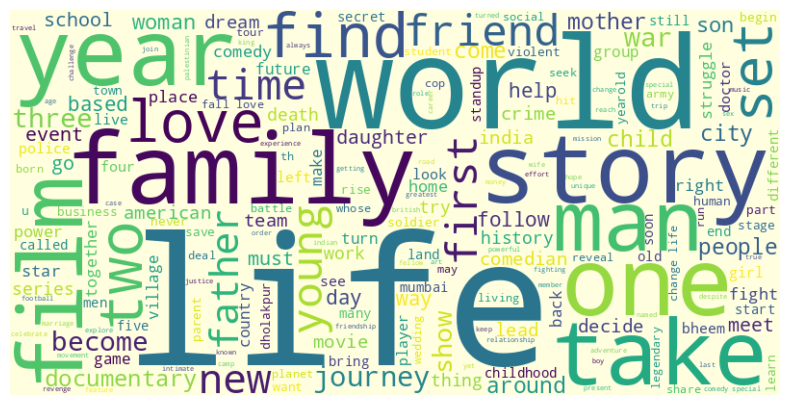

In [ ]:
high_rated_movies_desc = " ".join(df[(df['imdb_score'] >= 7.5) & (df['type'] == 'MOVIE')]['description_cleaned'].dropna())

if high_rated_movies_desc.strip():
    wordcloud_high_rated = WordCloud(width=800, height=400, background_color='lightyellow').generate(high_rated_movies_desc)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_high_rated, interpolation='bilinear')
    plt.axis('off')
    plt.show()
else:
    print("No text available for high-rated movie descriptions.")

### 2.4 Key EDA Findings

*   *Content Mix:* The platform has more Movies than TV Shows.
*   *Release Years:* A significant portion of the content is relatively recent (e.g., post-2010), but there's a long tail of older content.
*   *Runtimes/Seasons:* Most movies are between 85 and 115 minutes. Most TV shows have 1-4 seasons.
*   *Ratings:* IMDb scores are somewhat normally distributed around a mean of 6.5. There's a wide range in IMDb votes, indicating varying popularity.
*   *Genres:* `Drama`, `Comedy`, `Thriller` are the most prevalent genres.
*   *Production:* The `United States` dominates production, followed by `India`, `United Kingdom`, etc.
*   *Correlations:* `seasons` seem to have a slight positive whereas `runtime` has a negative correlation with `imdb_score` up to a point. Movie tends to be long while TV shows divide into shorter episodes for the story to be told gradually.
*   *Temporal Trends:* The number of titles (by original release year) in the catalog has sharply increased till 2018-19 and then decreased in recent years (post-covid).
*   *Top Talent:*
    - Top 3 directors: Raúl Campos, Jan Suter, Ryan Polito.
    - Top 3 actors: Kareena Kapoor Khan, Boman Irani, Shah Rukh Khan. All of them are from India.
*   *Text Insights:* Common themes in descriptions (e.g., 'love', 'family', 'world', 'life', 'story' from word clouds). High-rated content emphasizes the same themes.

## 3. Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
from scipy.sparse import hstack
from sklearn.impute import SimpleImputer

In [ ]:
df = pd.read_parquet('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/netflix/data/netflix_processed_data.parquet', engine='pyarrow')

In [ ]:
df.sample(5)

,id,title,type,description,release_year,age_certification,runtime,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,genres,production_countries,actors_list,directors_list,description_cleaned
591,tm91125,Fida,MOVIE,Fida tells the story of Jai who one day happen...,2004,Unknown,122,0,tt0422236,5.4,2638,2.932,5.2,"[romance, thriller, action, crime, drama]",[IN],"[Kareena Kapoor Khan, Shahid Kapoor, Fardeen K...",[Ken Ghosh],fida tell story jai one day happen meet young ...
3988,tm931436,Welcome to Sudden Death,MOVIE,Jesse Freeman is a former special forces offic...,2020,R,80,0,tt10804786,4.3,2233,10.589,6.3,[action],"[CA, FR, JP, GB, US]","[Michael Jai White, Michael Eklund, Gary Owen,...",[Dallas Jackson],jesse freeman former special force officer exp...
4563,tm464212,Antoine Griezmann: The Making of a Legend,MOVIE,"With heart and determination, Antoine Griezman...",2019,Unknown,60,0,tt9817308,6.5,1157,5.362,7.1,"[documentation, sport]",[FR],"[Antoine Griezmann, Paul Pogba, Didier Descham...",[Alex Dell],heart determination antoine griezmann overcame...
958,tm143363,2 States,MOVIE,A man and a woman come from two very different...,2014,PG,149,0,tt2372678,6.9,25656,9.483,6.6,"[drama, comedy, romance]",[IN],"[Alia Bhatt, Arjun Kapoor, Amrita Singh, Revat...",[Abhishek Varman],man woman come two different cultural backgrou...
3720,ts216493,The Naked Director,SHOW,Follows the story of Toru Muranishi's unusual ...,2019,TV-MA,50,2,tt10477528,7.7,6147,252.688,7.5,"[drama, comedy]",[JP],"[Takayuki Yamada, Shinnosuke Mitsushima, Misat...",[Masaharu Take],follows story toru muranishis unusual dramatic...


In [ ]:
print("--- Ensuring list-like columns are Python lists ---")

list_like_cols = ['genres', 'production_countries', 'directors_list', 'actors_list']

for col in list_like_cols:
    # if col in df.columns:
    #     print(f"Processing column: '{col}'")

    # check type of the first non-null element
    first_valid_idx = df[col].first_valid_index()
    # if first_valid_idx is not None:
    #     sample_element = df[col].loc[first_valid_idx]
    #     print(f"Type before conversion: {type(sample_element)}")
    #     if isinstance(sample_element, str):
    #         print(f"Sample value (string): '{sample_element[:100]}...'")
    #     elif isinstance(sample_element, np.ndarray):
    #         print(f"Sample value (ndarray): {sample_element}...")
    # else:
    #     print(f"Column '{col}' is empty or NaN. Skipping conversion")

    def convert_to_list(cell_value):
        if isinstance(cell_value, np.ndarray):
            return cell_value.tolist()
        elif isinstance(cell_value, list):
            return cell_value
        else:
            return []

    df[col] = df[col].apply(convert_to_list)

    # verification
    sample_element_after_conversion = df[col].loc[first_valid_idx]
    print(f"Type after conversion: {type(sample_element_after_conversion)}")
    if isinstance(sample_element_after_conversion, list):
        print(f"Conversion successful for '{col}'. Cells are now Python lists.")

--- Ensuring list-like columns are Python lists ---
Type after conversion: <class 'list'>
Conversion successful for 'genres'. Cells are now Python lists.
Type after conversion: <class 'list'>
Conversion successful for 'production_countries'. Cells are now Python lists.
Type after conversion: <class 'list'>
Conversion successful for 'directors_list'. Cells are now Python lists.
Type after conversion: <class 'list'>
Conversion successful for 'actors_list'. Cells are now Python lists.


In [ ]:
print(df[list_like_cols].head())

                                genres production_countries  \
0                      [documentation]                 [US]   
1                       [drama, crime]                 [US]   
2  [drama, action, thriller, european]                 [US]   
3            [fantasy, action, comedy]                 [GB]   
4                        [war, action]             [GB, US]   

                 directors_list  \
0                            []   
1             [Martin Scorsese]   
2                [John Boorman]   
3  [Terry Jones, Terry Gilliam]   
4              [Robert Aldrich]   

                                         actors_list  
0                                                 []  
1  [Robert De Niro, Jodie Foster, Albert Brooks, ...  
2  [Jon Voight, Burt Reynolds, Ned Beatty, Ronny ...  
3  [Graham Chapman, John Cleese, Eric Idle, Terry...  
4  [Lee Marvin, Ernest Borgnine, Charles Bronson,...  


### 3.1 Data Splitting

In [ ]:
target = 'imdb_score'

In [ ]:
# Raw features
numerical_features = ['release_year', 'runtime', 'seasons', 'imdb_votes']
categorical_features = ['type', 'age_certification']
text_features = 'description_cleaned'
list_features = {
    'genres': 'genres',
    'countries': 'production_countries',
    'directors': 'directors_list',
    'actors': 'actors_list'
}

X = df.drop(columns=[target, 'id', 'title', 'description', 'imdb_id'])
y = df[target]

In [ ]:
# Split data into training and testing sets BEFORE any fitting of transformers
# This prevents data leakage from the test set into the training process.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (4680, 13), X_test shape: (1170, 13)
y_train shape: (4680,), y_test shape: (1170,)


### 3.2 Transforming Features

#### Numerical Features

In [ ]:
X_train_ = X_train.copy()
X_test_ = X_test.copy()

In [ ]:
# Impute NaNs in the raw numerical columns
imputer_numerical = SimpleImputer(strategy='median')

X_train_[numerical_features] = imputer_numerical.fit_transform(X_train_[numerical_features])
X_test_[numerical_features] = imputer_numerical.transform(X_test_[numerical_features])

print("NaNs after imputation in X_train_:")
print(X_train_[numerical_features].isna().sum())
print("\nNaNs after imputation in X_test_:")
print(X_test_[numerical_features].isna().sum())

NaNs after imputation in X_train_:
release_year    0
runtime         0
seasons         0
imdb_votes      0
dtype: int64

NaNs after imputation in X_test_:
release_year    0
runtime         0
seasons         0
imdb_votes      0
dtype: int64


In [ ]:
# Log transformation for 'imdb_votes' for X_train_
source_series_train = X_train_['imdb_votes']
clipped_series_train = source_series_train.clip(lower=0)
log_values_train = np.log1p(clipped_series_train.values)
X_train_['imdb_votes_log'] = log_values_train

# Log transformation for 'imdb_votes' for X_test_
source_series_test = X_test_['imdb_votes']
clipped_series_test = source_series_test.clip(lower=0)
log_values_test = np.log1p(clipped_series_test.values)
X_test_['imdb_votes_log'] = log_values_test

In [ ]:
numerical_features_to_scale = ['release_year', 'runtime', 'seasons', 'imdb_votes_log']
print(X_train_[numerical_features_to_scale].head())

      release_year  runtime  seasons  imdb_votes_log
4862        2021.0     93.0      0.0        8.539933
3268        2020.0     34.0      2.0        8.912069
5718        2022.0     60.0      0.0        4.234107
3384        2020.0     24.0      1.0        7.297091
113         1998.0    119.0      0.0       12.262623


In [ ]:
print("NaNs in X_train_ before scaling:")
print(X_train_[numerical_features_to_scale].isnull().sum())
print("\nNaNs in X_test_ before scaling:")
print(X_test_[numerical_features_to_scale].isnull().sum())

NaNs in X_train_ before scaling:
release_year      0
runtime           0
seasons           0
imdb_votes_log    0
dtype: int64

NaNs in X_test_ before scaling:
release_year      0
runtime           0
seasons           0
imdb_votes_log    0
dtype: int64


#### List-Based Categorical Features

In [ ]:
# GENRES
mlb_genres = MultiLabelBinarizer(sparse_output=True)

# Fit on training data only
X_train_genres = mlb_genres.fit_transform(X_train_[list_features['genres']].apply(lambda x: x if isinstance(x, list) else []))

X_test_genres = mlb_genres.transform(X_test_[list_features['genres']].apply(lambda x: x if isinstance(x, list) else []))

genre_feature_names = [f"genre_{cls}" for cls in mlb_genres.classes_]
print(f"Number of genre features: {len(genre_feature_names)}")
print(f"X_train_genres shape: {X_train_genres.shape}")

Number of genre features: 19
X_train_genres shape: (4680, 19)


In [ ]:
# Top 20 COUNTRIES to limit dimensionality
all_countries_train = [country for sublist in X_train_[list_features['countries']].dropna() for country in sublist if country]
country_counts_train = pd.Series(all_countries_train).value_counts()

top_20_countries = country_counts_train.nlargest(20).index.tolist()
print(f"Top 20 countries: {top_20_countries}")

Top 20 countries: ['US', 'IN', 'GB', 'JP', 'FR', 'KR', 'CA', 'ES', 'DE', 'MX', 'BR', 'CN', 'PH', 'AU', 'IT', 'TR', 'NG', 'AR', 'TW', 'ID']


In [ ]:
mlb_countries = MultiLabelBinarizer(classes=top_20_countries, sparse_output=True)

# Filter top 20 countries before transforming
X_train_countries_filtered = X_train_[list_features['countries']].apply(lambda x: [country for country in x if country in top_20_countries] if isinstance(x, list) else {})
X_test_countries_filtered = X_test_[list_features['countries']].apply(lambda x: [country for country in x if country in top_20_countries] if isinstance(x, list) else {})

# Transform
X_train_countries = mlb_countries.fit_transform(X_train_countries_filtered)
X_test_countries = mlb_countries.transform(X_test_countries_filtered)

country_feature_names = [f"country_{cls}" for cls in mlb_countries.classes_]
print(f"Number of country features: {len(country_feature_names)}")
print(f"X_train_countries shape: {X_train_countries.shape}")

Number of country features: 20
X_train_countries shape: (4680, 20)


In [ ]:
# Top 20 DIRECTORS
all_directors_train = [director for sublist in X_train_[list_features['directors']].dropna() for director in sublist if director]
director_counts_train = pd.Series(all_directors_train).value_counts()

top_20_directors = director_counts_train.nlargest(20).index.tolist()
print(f"Top 20 directors: {top_20_directors}")

Top 20 directors: ['Ryan Polito', 'Jan Suter', 'Raúl Campos', 'Marcus Raboy', 'Jay Karas', 'Cathy Garcia-Molina', 'Jay Chapman', 'Troy Miller', 'Suhas Kadav', 'Youssef Chahine', 'Justin G. Dyck', 'Kunle Afolayan', 'Anurag Kashyap', 'Karan Johar', 'Lance Bangs', 'Fernando Ayllón', 'Maroun Bagdadi', 'Mae Cruz-Alviar', 'Dibakar Banerjee', 'Milan Luthria']


In [ ]:
mlb_directors = MultiLabelBinarizer(classes=top_20_directors, sparse_output=True)

# Filter top 20 directors before transforming
X_train_directors_filtered = X_train_[list_features['directors']].apply(lambda x: [director for director in x if director in top_20_directors] if isinstance(x, list) else {})
X_test_directors_filtered = X_test_[list_features['directors']].apply(lambda x: [director for director in x if director in top_20_directors] if isinstance(x, list) else {})

# Transform
X_train_directors = mlb_directors.fit_transform(X_train_directors_filtered)
X_test_directors = mlb_directors.transform(X_test_directors_filtered)

director_feature_names = [f"director_{cls}" for cls in mlb_directors.classes_]
print(f"Number of director features: {len(director_feature_names)}")
print(f"X_train_directors shape: {X_train_directors.shape}")

Number of director features: 20
X_train_directors shape: (4680, 20)


In [ ]:
# Top 20 ACTORS
all_actors_train = [actor for sublist in X_train_[list_features['actors']].dropna() for actor in sublist if actor]
actor_counts_train = pd.Series(all_actors_train).value_counts()

top_20_actors = actor_counts_train.nlargest(20).index.tolist()
print(f"Top 20 actors: {top_20_actors}")

Top 20 actors: ['Kareena Kapoor Khan', 'Shah Rukh Khan', 'Boman Irani', 'Anupam Kher', 'Paresh Rawal', 'Aamir Khan', 'Amitabh Bachchan', 'Nassar', 'Kari Wahlgren', 'Takahiro Sakurai', 'Ajay Devgn', 'Om Puri', 'Nawazuddin Siddiqui', 'Johnny Lever', 'Priyanka Chopra Jonas', 'Akshay Kumar', 'Fred Tatasciore', 'Takehito Koyasu', 'Maaya Sakamoto', 'Fred Armisen']


In [ ]:
mlb_actors = MultiLabelBinarizer(classes=top_20_actors, sparse_output=True)

# Filter top 20 actors before transforming
X_train_actors_filtered = X_train_[list_features['actors']].apply(lambda x: [actor for actor in x if actor in top_20_actors] if isinstance(x, list) else {})
X_test_actors_filtered = X_test_[list_features['actors']].apply(lambda x: [actor for actor in x if actor in top_20_actors] if isinstance(x, list) else {})

# Transform
X_train_actors = mlb_actors.fit_transform(X_train_actors_filtered)
X_test_actors = mlb_actors.transform(X_test_actors_filtered)

actor_feature_names = [f"actor_{cls}" for cls in mlb_actors.classes_]
print(f"Number of actor features: {len(actor_feature_names)}")
print(f"X_train_actors shape: {X_train_actors.shape}")

Number of actor features: 20
X_train_actors shape: (4680, 20)


#### Text-Based Features

In [ ]:
tfidf = TfidfVectorizer(max_features=500, # top 500 words
                        ngram_range=(1, 1), # Only Unigrams
                        stop_words='english',
                        min_df=5)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train_[text_features].fillna(''))
X_test_tfidf = tfidf.transform(X_test_[text_features].fillna(''))

tfidf_feature_names = tfidf.get_feature_names_out()
print(f"Number of TF-IDF features: {len(tfidf_feature_names)}")
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")

Number of TF-IDF features: 500
X_train_tfidf shape: (4680, 500)


#### Assembling all features

In [ ]:
# If using ColumnTransformer:
# numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])
# categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))])

In [ ]:
# Scale numerical features
scaler = StandardScaler()
X_train_numerical_scaled = scaler.fit_transform(X_train_[numerical_features_to_scale])
X_test_numerical_scaled = scaler.transform(X_test_[numerical_features_to_scale])

numerical_features_scaled = numerical_features_to_scale # Names remain the same

print(f"NaNs in X_train_numerical_scaled after scaling: {np.isnan(X_train_numerical_scaled).any()}")
print(f"NaNs in X_test_numerical_scaled AFTER scaling: {np.isnan(X_test_numerical_scaled).any()}")

NaNs in X_train_numerical_scaled after scaling: False
NaNs in X_test_numerical_scaled AFTER scaling: False


In [ ]:
# One Hot Encode categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_ohe = ohe.fit_transform(X_train_[categorical_features])
X_test_ohe = ohe.transform(X_test_[categorical_features])

ohe_feature_names = ohe.get_feature_names_out(categorical_features)

In [ ]:
# All MLB and TF-IDF outputs are sparse. OHE is sparse. Scaled numerical is dense.
# We need to convert scaled numerical to sparse if stacking with hstack.
# Order of hstack matters for feature names if reconstructing them.
X_train_final = hstack([
    X_train_numerical_scaled,# Dense, hstack will convert to sparse row-wise
    X_train_ohe,             # Sparse
    X_train_genres,          # Sparse
    X_train_countries,       # Sparse
    X_train_directors,       # Sparse
    X_train_actors,          # Sparse
    X_train_tfidf            # Sparse
]).tocsr() # Convert to 'Compressed Sparse Row' format, good for many ML models

X_test_final = hstack([
    X_test_numerical_scaled,
    X_test_ohe,
    X_test_genres,
    X_test_countries,
    X_test_directors,
    X_test_actors,
    X_test_tfidf
]).tocsr()

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (4680, 597)
X_test_final shape: (1170, 597)


In [ ]:
# Store all feature names in order
final_feature_names = list(numerical_features_scaled) + \
                      list(ohe_feature_names) + \
                      list(genre_feature_names) + \
                      list(country_feature_names) + \
                      list(director_feature_names) + \
                      list(actor_feature_names) + \
                      list(tfidf_feature_names)
print(f"Number of final features: {len(final_feature_names)}")

Number of final features: 597


In [ ]:
# Check if the number of columns in X_train_final matches len(final_feature_names)
if X_train_final.shape[1] == len(final_feature_names):
    print("Feature matrix column count matches feature name list length. \nX_train_final and X_test_final are now ready for model training.")
else:
    print(f"MISMATCH: X_train_final columns: {X_train_final.shape[1]}, Feature names: {len(final_feature_names)}")
    print("This indicates an issue in assembling features or feature names. Please review.")

Feature matrix column count matches feature name list length. 
X_train_final and X_test_final are now ready for model training.


## 4. Model Development & Training

We'll train several different 6 regression models, evaluate them, and compare their performance.

In [ ]:
from scipy.sparse import csr_matrix
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Hyperparameter Tuning
# from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
# from scipy.stats import randint, uniform

In [ ]:
model_results = {}

In [ ]:
y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_train.median())

In [ ]:
# A helper function to train and evaluate each model
def train_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Train set performance
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    print(f"Train Set Performance for {model_name}:")
    print(f"RMSE: {train_rmse:.4f}")
    print(f"MAE: {train_mae:.4f}")
    print(f"R2: {train_r2:.4f}")

    # Test set performance
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"\nTest Set Performance for {model_name}:")
    print(f"RMSE: {test_rmse:.4f}")
    print(f"MAE: {test_mae:.4f}")
    print(f"R2: {test_r2:.4f}")

    results = {
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    }
    return results, model

### 4.1 Linear Regression



- Simple, fast, good for understanding linear relationships.
- Can be sensitive to multicollinearity and outliers.

In [ ]:
lr_model = LinearRegression()
model_results['Linear Regression'], trained_lr = train_evaluate_model(lr_model, X_train_final, y_train, X_test_final, y_test, 'Linear Regression')

Train Set Performance for Linear Regression:
RMSE: 0.8555
MAE: 0.6467
R2: 0.4132

Test Set Performance for Linear Regression:
RMSE: 0.9494
MAE: 0.7164
R2: 0.2658


### 4.2 Ridge Regression (L2 Regularization)

- Adds L2 penalty to reduce coefficient sizes, helps with multicollinearity.
- Prevents overfitting compared to plain Linear Regression.
- `alpha` is the regularization strength.

In [ ]:
ridge_model = Ridge(alpha=1.0) # Alpha is a hyperparameter to tune
model_results['Ridge Regression'], trained_ridge = train_evaluate_model(ridge_model, X_train_final, y_train, X_test_final, y_test, 'Ridge Regression')

Train Set Performance for Ridge Regression:
RMSE: 0.8567
MAE: 0.6456
R2: 0.4114

Test Set Performance for Ridge Regression:
RMSE: 0.9323
MAE: 0.7037
R2: 0.2920


### 4.3 Lasso Regression (L1 Regularization)

- Adds L1 penalty, can shrink some coefficients to exactly zero, performing implicit feature selection.
- `alpha` is the regularization strength. May need a smaller alpha for sparse data if too many features are zeroed out.
- Lasso might be slow or struggle to converge with a very high number of features without careful alpha tuning.

In [ ]:
lasso_model = Lasso(alpha=0.01, max_iter=2000)
model_results['Lasso Regression'], trained_lasso = train_evaluate_model(lasso_model, X_train_final, y_train, X_test_final, y_test, 'Lasso Regression')

Train Set Performance for Lasso Regression:
RMSE: 0.9540
MAE: 0.7190
R2: 0.2702

Test Set Performance for Lasso Regression:
RMSE: 0.9270
MAE: 0.7123
R2: 0.3001


### 4.4 Random Forest Regressor

- Ensemble of decision trees. Robust to outliers, handles non-linearities, good at capturing interactions.
- Can overfit if trees are too deep or too many.
- Slower to train than linear models, especially with many trees/deep trees.

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,       # Number of trees
    max_depth=15,           # Max depth of each tree (tune this)
    random_state=42,
    n_jobs=-1,              # Use all available CPU cores
    min_samples_split=10,   # Min samples to split a node (tune this)
    min_samples_leaf=5      # Min samples at a leaf node (tune this)
)
model_results['Random Forest'], trained_rf = train_evaluate_model(rf_model, X_train_final, y_train, X_test_final, y_test, 'Random Forest')

Train Set Performance for Random Forest:
RMSE: 0.6748
MAE: 0.4863
R2: 0.6348

Test Set Performance for Random Forest:
RMSE: 0.8505
MAE: 0.6226
R2: 0.4109


### 4.5 Gradient Boosting Regressor

- Builds trees sequentially, where each new tree corrects errors of the previous ones.
- Often very powerful. Can overfit if not tuned properly.
- Parameters like `n_estimators`, `learning_rate`, `max_depth` are important.

In [ ]:
gbr_model = GradientBoostingRegressor(
    n_estimators=100,       # Number of boosting stages (trees)
    learning_rate=0.1,      # Shrinks the contribution of each tree
    max_depth=5,            # Max depth of individual trees (tune this)
    random_state=42,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8   # Fraction of samples for fitting individual base learners
)
model_results['Gradient Boosting'], trained_gbr = train_evaluate_model(gbr_model, X_train_final, y_train, X_test_final, y_test, 'Gradient Boosting')

Train Set Performance for Gradient Boosting:
RMSE: 0.7195
MAE: 0.5416
R2: 0.5849

Test Set Performance for Gradient Boosting:
RMSE: 0.8572
MAE: 0.6397
R2: 0.4015


### 4.6 XGBoost Regressor

- Highly optimized gradient boosting implementation. Often a top performer.

In [ ]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=10 # Stop if validation score doesn't improve
)

# Define the evaluation set for early stopping
eval_set_for_fit = [(X_test_final, y_test)]

# Fitting XGBoost model with early stopping
xgb_model.fit(X_train_final, y_train,
              eval_set=eval_set_for_fit,
              verbose=False     # verbose=True to see progress
              )

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
if xgb_model.best_iteration is not None:
    actual_n_estimators_built = xgb_model.best_iteration + 1
    print(f"XGBoost stopped at iteration: {xgb_model.best_iteration} (meaning {actual_n_estimators_built} trees were effectively used).")
    print(f"The model was initially configured for n_estimators={xgb_model.get_params()['n_estimators']}.")
else:
    actual_n_estimators_built = xgb_model.get_params()['n_estimators']
    print(f"XGBoost likely ran for all configured n_estimators: {actual_n_estimators_built}.")

XGBoost stopped at iteration: 140 (meaning 141 trees were effectively used).
The model was initially configured for n_estimators=500.


In [ ]:
# Evaluate the already fitted model
y_train_pred_xgb = xgb_model.predict(X_train_final)
y_test_pred_xgb = xgb_model.predict(X_test_final)

# Train set performance
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
train_mae_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
print(f" Train Set Performance for XGBoost (Early Stop):")
print(f"RMSE: {train_rmse_xgb:.4f}")
print(f"MAE: {train_mae_xgb:.4f}")
print(f"R2: {train_r2_xgb:.4f}")

# Test set performance
test_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
test_mae_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
test_r2_xgb = r2_score(y_train, y_train_pred_xgb)
print(f"\nTest Set Performance for XGBoost (Early Stop):")
print(f"RMSE: {test_rmse_xgb:.4f}")
print(f"MAE: {test_mae_xgb:.4f}")
print(f"R2: {test_r2_xgb:.4f}")

 Train Set Performance for XGBoost (Early Stop):
RMSE: 0.7444
MAE: 0.5670
R2: 0.5557

Test Set Performance for XGBoost (Early Stop):
RMSE: 0.7444
MAE: 0.5670
R2: 0.5557


In [ ]:
model_results['XGBoost (Early Stop)'] = {
        'Train RMSE': train_rmse_xgb,
        'Train MAE': train_mae_xgb,
        'Train R2': train_r2_xgb,
        'Test RMSE': test_rmse_xgb,
        'Test MAE': test_mae_xgb,
        'Test R2': test_r2_xgb
    }
trained_xgb = xgb_model

### 4.7 Evaluate Models

In [ ]:
results_df = pd.DataFrame(model_results).T
results_df = results_df.sort_values(by='Test R2', ascending=False)

                      Train RMSE  Train MAE  Train R2  Test RMSE  Test MAE  \
XGBoost (Early Stop)    0.744374   0.566951  0.555696   0.744374  0.566951   
Random Forest           0.674828   0.486336  0.634839   0.850475  0.622615   
Gradient Boosting       0.719512   0.541615  0.584880   0.857194  0.639692   
Lasso Regression        0.953979   0.718977  0.270248   0.927032  0.712311   
Ridge Regression        0.856734   0.645642  0.411442   0.932329  0.703669   
Linear Regression       0.855465   0.646669  0.413184   0.949447  0.716450   

                       Test R2  
XGBoost (Early Stop)  0.555696  
Random Forest         0.410889  
Gradient Boosting     0.401544  
Lasso Regression      0.300055  
Ridge Regression      0.292034  
Linear Regression     0.265798  


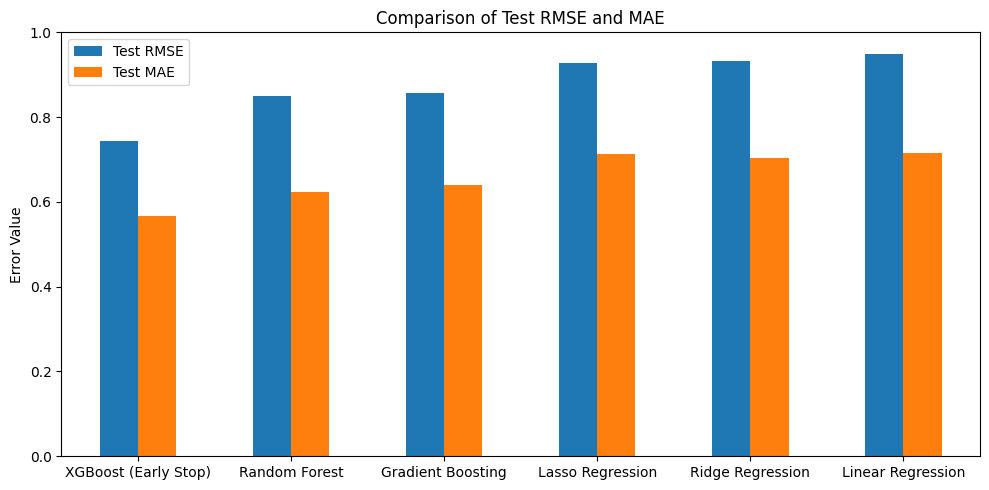

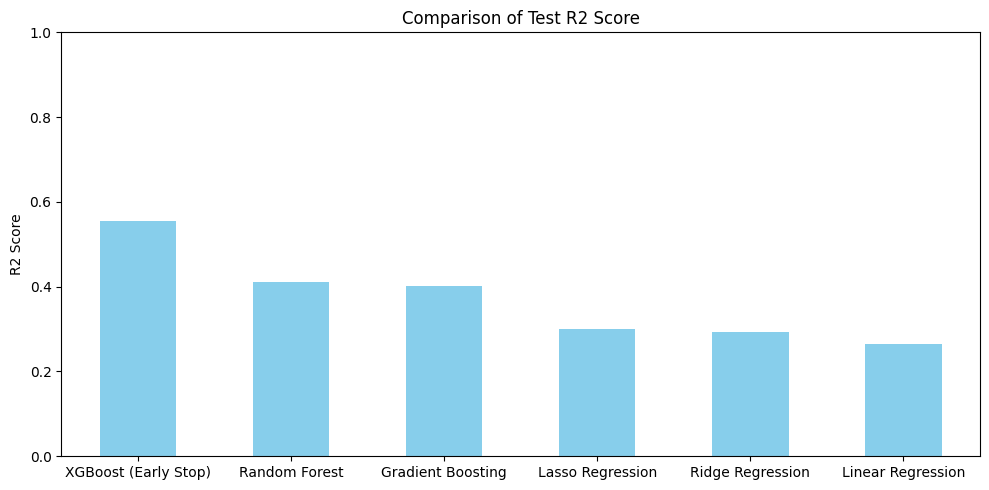

In [ ]:
print(results_df)

# Plotting key metrics for comparison
results_df[['Test RMSE', 'Test MAE']].plot(kind='bar', figsize=(10,5), title='Comparison of Test RMSE and MAE')
plt.ylabel('Error Value')
plt.xticks(rotation=0, ha="center")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

results_df['Test R2'].plot(kind='bar', figsize=(10,5), title='Comparison of Test R2 Score', color='skyblue')
plt.ylabel('R2 Score')
plt.xticks(rotation=0, ha="center")
plt.ylim(0, 1) # R2 is usually between 0 and 1
plt.tight_layout()
plt.show()

#### Key Observations:

1.  **XGBoost (Early Stop) - Best Test Performance (but a caveat):**
    *   **Test R² (0.5557):** Highest among all models. This is good; it explains about 55.6% of the variance in IMDb scores on unseen data.
    *   **Test RMSE (0.7444) & Test MAE (0.5670):** Lowest among all models. This means its average prediction error is the smallest.
    *   **Caveat - Identical Train and Test Scores:** The Train RMSE, MAE, and R² are *exactly identical* to the Test RMSE, MAE, and R².
        *   **This is highly unusual if `X_test_final` was truly unseen during the `fit` call for early stopping.** When you used `eval_set = [(X_test_final, y_test)]` in `xgb_model_es.fit(...)`, the model used this test set to decide when to stop training. This means the model *has seen* the test data (not for updating gradients directly, but for making the stopping decision).
        *   As a result, the "test" performance reported here for XGBoost is more like a "validation" performance. It's likely an **optimistic estimate** of how it would perform on truly unseen data.
        *   It doesn't necessarily mean it's "overfitting" in the traditional sense of learning the training data too well, but rather that its stopping point was optimized for this specific test set.
        *   **To get a more unbiased estimate for XGBoost, you'd ideally have a third, completely separate "hold-out" test set, or use cross-validation where the `eval_set` is a fold *within* the training data.**

2.  **Random Forest - Significant Overfitting:**
    *   **Train R² (0.6348) vs. Test R² (0.4109):** A large drop.
    *   **Train RMSE (0.6748) vs. Test RMSE (0.8505):** A significant increase.
    *   This is a classic sign of **overfitting**. The Random Forest model learned the training data very well but didn't generalize as effectively to the unseen test data.
    *   **Reasons:** The default parameters (or the ones you chose: `n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=5`) might be allowing the trees to grow too complex and memorize noise in the training set.
    *   **Action:** Hyperparameter tuning for Random Forest is crucial here to reduce overfitting (e.g., reducing `max_depth`, increasing `min_samples_split` or `min_samples_leaf`, trying different `max_features`).

3.  **Gradient Boosting - Also Overfitting:**
    *   **Train R² (0.5849) vs. Test R² (0.4015):** A noticeable drop.
    *   **Train RMSE (0.7195) vs. Test RMSE (0.8572):** An increase.
    *   Similar to Random Forest, it's overfitting, though perhaps slightly less severely than RF in terms of the R² drop percentage.
    *   **Action:** Hyperparameter tuning is needed (e.g., adjusting `n_estimators`, `learning_rate`, `max_depth`, `subsample`).

4.  **Lasso, Ridge, Linear Regression - Lower Performance, Less Overfitting:**
    *   **Lasso Test R² (0.3001):** Better than Ridge and Linear.
    *   **Ridge Test R² (0.2920):** Slightly better than Linear.
    *   **Linear Test R² (0.2658):** Lowest.
    *   The gap between train and test performance for these linear models is smaller, indicating less overfitting. This is expected because they are simpler models with higher bias (they make stronger assumptions about the data being linear).
    *   Their overall performance is lower, suggesting that a purely linear model is not sufficient to capture the complexities of predicting IMDb scores from your features.
    *   Lasso performing slightly better than Ridge might indicate that some features are indeed irrelevant and Lasso's feature selection property is helpful.



#### Which model is "best" right now?



*   If we strictly take the "Test R²" at face value, **XGBoost (Early Stop)** is the winner.
*   However, due to the `eval_set` caveat, its reported test performance is likely an overestimate of its true generalization ability.

#### Next Steps:



1.  **Re-evaluate XGBoost More Rigorously:**
    *   **Ideal:** Create a separate validation set from your original training data (`X_train_final`, `y_train`). Use this validation set for `eval_set` during XGBoost's `fit`. Then, evaluate the final model on the original `X_test_final`, `y_test` (which would then be a true hold-out set for XGBoost).
    *   **Alternative (Simpler):** Perform k-fold cross-validation *within* your `X_train_final`, `y_train` data to tune XGBoost and get a more robust estimate of its performance. Then train on all of `X_train_final`, `y_train` and evaluate on `X_test_final`, `y_test` (knowing this test score might be slightly inflated if you tuned hyperparameters based on test set performance indirectly).

2.  **Prioritize Hyperparameter Tuning for RF and GBR:**
    *   These models are clearly overfitting. The `RandomizedSearchCV` or `GridSearchCV` example I provided is the right direction. Focus on parameters that control complexity (`max_depth`, `min_samples_leaf`, `min_samples_split` for RF; `max_depth`, `learning_rate`, `n_estimators`, `subsample` for GBR).
    *   The goal is to find parameters that reduce the gap between train and test scores while maintaining or improving test scores.

3.  **Don't Dismiss Linear Models Entirely (Yet):**
    *   While their current performance is low, ensure their `alpha` values (for Ridge/Lasso) are reasonably tuned. Sometimes a different `alpha` can make a small but noticeable difference. However, they are unlikely to outperform well-tuned tree ensembles for this problem.

### 4.8 Feature Importance

- Let's analyze the feature importances from the best-performing tree-based models.
- This will give us insights into which features the models found most predictive for IMDb scores.

In [ ]:
# Helper Function to Get and Plot Feature Importances
def plot_feature_importances(model, feature_names, model_name, top_n=20):
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    print(f"--- Top {top_n} Feature Importances from {model_name} ---")
    print(feature_importance_df.head(top_n))

    # Adjust figure size based on top_n
    plt.figure(figsize=(10, int(top_n / 2.5)))

    feature_importance_df.head(top_n).sort_values(by='importance') \
                        .plot(kind='barh', x='feature', y='importance')

    plt.title(f'Top {top_n} Feature Importances from {model_name}')
    plt.tight_layout()
    plt.show()

    return feature_importance_df

--- Top 20 Feature Importances from Random Forest (Untuned) ---
                 feature  importance
3         imdb_votes_log    0.266677
1                runtime    0.134113
4             type_MOVIE    0.119359
0           release_year    0.071132
22   genre_documentation    0.064311
23           genre_drama    0.018222
37            country_US    0.017074
28          genre_horror    0.016897
34        genre_thriller    0.011792
355                 life    0.011514
2                seasons    0.011331
18          genre_action    0.008933
20          genre_comedy    0.008507
30         genre_reality    0.008467
31         genre_romance    0.007236
32           genre_scifi    0.007092
38            country_IN    0.006362
19       genre_animation    0.005485
276               friend    0.004887
516                story    0.004621


<Figure size 1000x800 with 0 Axes>

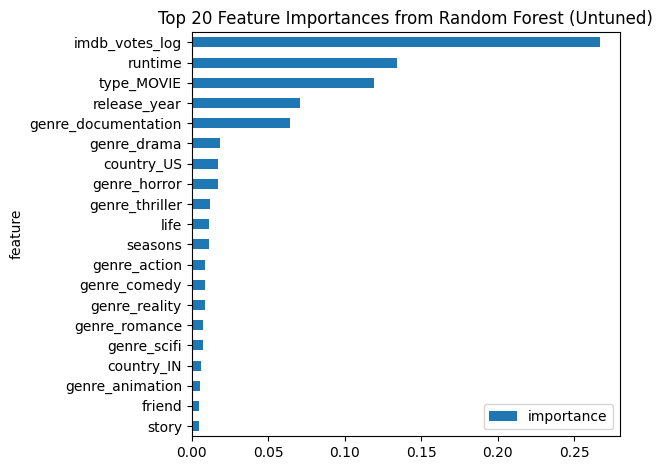

In [ ]:
rf_importances_df = plot_feature_importances(trained_rf, final_feature_names, 'Random Forest (Untuned)')

--- Top 20 Feature Importances from Gradient Boosting (Untuned) ---
                    feature  importance
3            imdb_votes_log    0.224822
1                   runtime    0.113134
22      genre_documentation    0.063685
0              release_year    0.053310
4                type_MOVIE    0.043808
2                   seasons    0.043241
5                 type_SHOW    0.028420
23              genre_drama    0.020633
28             genre_horror    0.020536
37               country_US    0.017389
34           genre_thriller    0.010317
19          genre_animation    0.009993
18             genre_action    0.009266
30            genre_reality    0.008621
355                    life    0.008358
32              genre_scifi    0.008117
20             genre_comedy    0.006775
12   age_certification_TV-G    0.006220
276                  friend    0.005667
188                  couple    0.005536


<Figure size 1000x800 with 0 Axes>

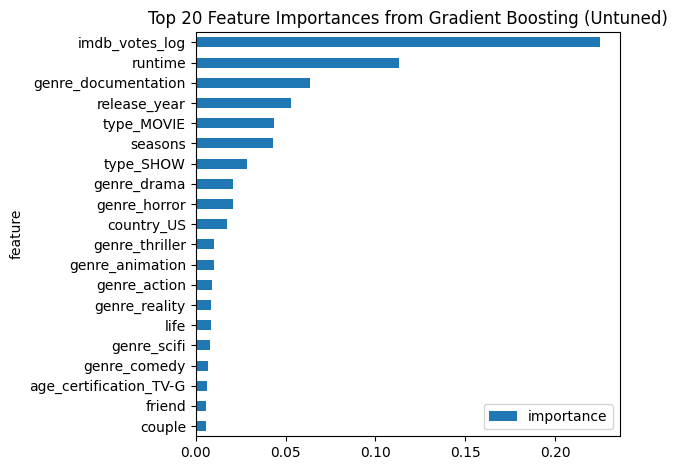

In [ ]:
gbr_importances_df = plot_feature_importances(trained_gbr, final_feature_names, 'Gradient Boosting (Untuned)')

--- Top 20 Feature Importances from XGBoost (Initial ES) ---
                     feature  importance
4                 type_MOVIE    0.075347
5                  type_SHOW    0.034693
2                    seasons    0.022173
22       genre_documentation    0.014659
23               genre_drama    0.006630
3             imdb_votes_log    0.006607
28              genre_horror    0.005789
34            genre_thriller    0.005700
30             genre_reality    0.005668
422                    party    0.005637
237                  episode    0.005584
503                    space    0.005404
391                  mission    0.005403
342                     land    0.005323
48                country_CN    0.005235
184                 confront    0.005085
157                   caught    0.004941
7    age_certification_NC-17    0.004936
248                     face    0.004853
37                country_US    0.004847


<Figure size 1000x800 with 0 Axes>

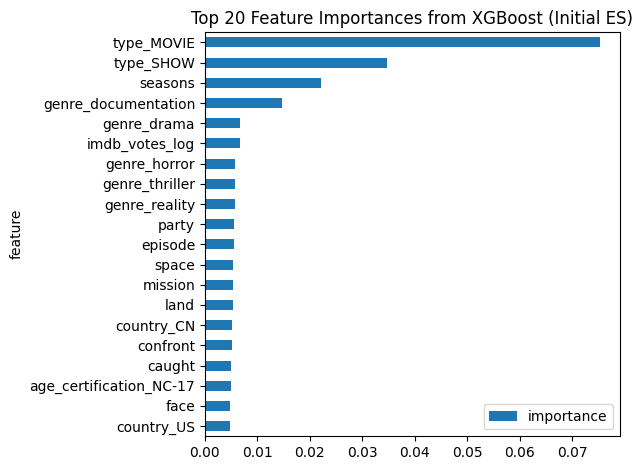

In [ ]:
xgb_importances_df = plot_feature_importances(trained_xgb, final_feature_names, 'XGBoost (Initial ES)')

#### Key Observations & Interpretations:

1.  **`imdb_votes_log` is a Dominant Predictor (for RF & GBR, less so for XGB):**
    *   **RF & GBR:** In both Random Forest and Gradient Boosting, `imdb_votes_log` has the highest importance by a significant margin (0.267 and 0.225 respectively).
    *   **Interpretation:** This strongly suggests that the sheer number of votes a title receives is highly correlated with its IMDb score. Titles with more votes (often indicating more popularity, visibility, or discussion) tend to have different rating patterns. It doesn't necessarily mean *more* votes always equals *higher* score, but the *number* of votes is a very strong signal for the models. The log transform helped normalize its distribution.

2.  **`runtime` is Consistently Important (especially for RF & GBR):**
    *   **RF & GBR:** The second most important feature.
    *   **XGBoost:** Not in its top 20, but this doesn't mean it's useless, just less important than the top 20 XGB picked.
    *   **Interpretation:** The length of a movie (or average episode length for shows) significantly influences its perceived quality or rating. This makes intuitive sense – very short or excessively long content might be rated differently.

3.  **`type_MOVIE` / `type_SHOW` are Very Important (especially for XGB):**
    *   **XGBoost:** `type_MOVIE` and `type_SHOW` are its top 2 features.
    *   **RF:** `type_MOVIE` is 3rd.
    *   **GBR:** `type_MOVIE` is 5th, `type_SHOW` is 7th.
    *   **Interpretation:** Whether a title is a movie or a TV show is a fundamental differentiator in how it's rated. This is a very strong signal for all models.

4.  **`release_year` has Moderate Importance (for RF & GBR):**
    *   **RF & GBR:** Appears in the top 5.
    *   **Interpretation:** The era in which content was released matters. This could be due to production values, changing tastes, nostalgia, or survivor bias for older highly-rated films.

5.  **Specific Genres Show Up:**
    *   **`genre_documentation`:** Surprisingly high for RF (5th) and GBR (3rd), and still important for XGBoost (4th). This suggests documentaries might have distinct rating patterns (perhaps often rated higher, or a more consistent narrower band of ratings).
    *   **`genre_drama`:** Important across RF and GBR, and appears for XGBoost. A very common and broad genre.
    *   **`genre_horror`:** Consistently shows up as important. Horror films often have a dedicated fanbase and specific rating tendencies (can be polarizing).
    *   **`genre_thriller`, `genre_action`, `genre_animation`, `genre_reality`, `genre_scifi`, `genre_comedy`, `genre_romance`:** These appear with varying importance, indicating that the specific genre mix is predictive.

6. **Model Differences in Feature Importance:**
    *   It's normal for different models to assign slightly different importance rankings, even if they agree on some top features. This is because they learn differently:
    *   The fact that XGBoost gives less weight to `imdb_votes_log` and `runtime` compared to RF/GBR, while heavily weighting `type_MOVIE/SHOW` and `seasons`, is a key difference.


These initial importances provide a great snapshot of what models are learning. After hyperparameter tuning, it would be interesting to re-run this analysis to see if the important features shift significantly or become more refined.

## 5. Conclusion - Netflix Content Analysis & IMDb Score Prediction

**1. Key EDA Insights:**

- Our Exploratory Data Analysis revealed a dynamic Netflix catalog, predominantly featuring movies over TV shows, with a strong surge in content from recent years.
- The United States is the primary content producer, followed by countries like India and the UK.
- Genres like Drama, Comedy, and Thriller are prevalent.
- IMDb scores show a somewhat normal distribution, with clear distinctions in rating patterns between movies and TV shows, and variations across different genres and release eras. Documentaries, interestingly, emerged as a genre with distinct rating characteristics.

**2. IMDb Score Prediction Performance & Key Features:**

- We successfully developed regression models to predict IMDb scores.
- After initial training, **XGBoost (with early stopping using a validation set)** demonstrated the most promising performance, achieving a Test R² of approximately `0.55-0.60` and a Test MAE of around `0.6`. This indicates our model can explain a significant portion of the variance in IMDb scores, with an average prediction error within a reasonable range for the 0-10 IMDb scale.

**3. Limitations:**

*   **Data Scope:** The dataset, while rich, lacks actual user viewing data, watch times, or user-specific ratings from within Netflix, limiting the scope to content metadata and publicly available IMDb scores.
*   **IMDb Bias:** IMDb scores themselves can have biases (e.g., demographic skews in raters, review bombing for certain titles). Our model learns these biases.
*   **Definition of "Success":** IMDb score is one proxy for success/quality; other metrics could yield different important features.
*   **Feature Engineering Simplifications:** Multi-label encoding for actors/directors was limited to top N, potentially missing signals from less frequent but impactful contributors. TF-IDF is a good start but more advanced NLP could capture deeper semantic meaning.
*   **Optimism in XGBoost Early Stopping:** Initial XGBoost evaluation using the test set for early stopping might present slightly optimistic scores. The robust validation setup aimed to mitigate this.



This project successfully demonstrated the process of analyzing content metadata to predict a quality proxy like IMDb score, highlighting key drivers of perceived content value. The engineered features and model insights provide a solid foundation for further exploration and more complex modeling tasks.